# 海龟交易法则策略回测

## 策略规则
- 股票池：流动性最好的前 50 只股票
- 入场：价格突破 20 日最高价买入
- 出场：价格跌破 10 日最低价卖出
- 仓位管理：基于 ATR 计算头寸规模（每单位风险 = 账户净值的 1%）
- 加仓：每上涨 0.5 个 ATR 加仓一个单位，最多加仓 4 次
- 止损：初始止损为 2 个 ATR，加仓后止损上移
- 空仓条件：没有满足条件的股票时，空仓
- 回测时间：2023-01-01 ~ 2026-08-22
- 手续费：佣金万3 + 印花税千0.5

In [1]:
import sys
sys.path.insert(0, '/Users/riceball/Documents/Projs/fund')

import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from screener.liquidity import LiquidityScreener
from backtest.turtle import TurtleStrategy

## 1. 数据加载和流动性筛选

In [2]:
# 流动性筛选
screener = LiquidityScreener(
    data_dir='/Users/riceball/Documents/Projs/fund/data',
    top_n=50,  # 选择前 50 只股票
    min_daily_amount=1e7,  # 最低日成交额 1000 万
    min_daily_volume=1e6,  # 最低日成交量 100 万股
    lookback_days=252  # 回看一年
)

result = screener.run()
print(f'筛选结果: {result.info}')
print(f'选中股票数量: {len(result.codes)}')
print(f'股票名称映射: {result.names}')

筛选结果: {'total_stocks': 4274, 'qualified_stocks': 3576, 'selected_stocks': 50, 'top_stocks': [{'code': '300308', 'avg_daily_amount': 23637621601.02591, 'avg_daily_volume': 36235379.32539683, 'total_amount': 5956680643458.529, 'min_amount_check': True, 'min_volume_check': True, 'data_points': 252}, {'code': '300502', 'avg_daily_amount': 15561888964.90881, 'avg_daily_volume': 46265968.71031746, 'total_amount': 3921596019157.02, 'min_amount_check': True, 'min_volume_check': True, 'data_points': 252}, {'code': '300476', 'avg_daily_amount': 12548040454.762222, 'avg_daily_volume': 43019803.24206349, 'total_amount': 3162106194600.08, 'min_amount_check': True, 'min_volume_check': True, 'data_points': 252}, {'code': '300750', 'avg_daily_amount': 12384417236.776785, 'avg_daily_volume': 33299652.293650795, 'total_amount': 3120873143667.75, 'min_amount_check': True, 'min_volume_check': True, 'data_points': 252}, {'code': '601138', 'avg_daily_amount': 11840376780.148016, 'avg_daily_volume': 19447527

In [3]:
# 加载选中股票的市场数据
DATA_DIR = Path('/Users/riceball/Documents/Projs/fund/data')
market_data = {}

for code in result.codes:
    file_path = DATA_DIR / f'{code}_qfq.csv'
    if file_path.exists():
        df = pd.read_csv(file_path)
        df['date'] = pd.to_datetime(df['date'])
        df.set_index('date', inplace=True)
        if len(df) > 100:  # 确保有足够数据
            market_data[code] = df

print(f'加载市场数据的股票数量: {len(market_data)}')

加载市场数据的股票数量: 50


## 2. 策略回测

In [4]:
# 初始化策略
strategy = TurtleStrategy(
    initial_capital=1_000_000,
    entry_period=20,
    exit_period=10,
    atr_period=20,
    risk_per_trade=0.01,
    max_units=4,
    add_threshold=0.5,
    stop_loss_atr=2.0,
    commission=0.0003,
    stamp_tax=0.0005,
    stock_names=result.names
)

# 运行回测
nav_history = strategy.run(
    market_data=market_data,
    start_date='2023-01-01',
    end_date='2026-08-22'
)

回测期间: 2023-01-01 ~ 2026-08-22, 共 876 个交易日
  进度: 100/876, 净值: 1,326,187, 持仓: 6
  进度: 200/876, 净值: 1,317,056, 持仓: 5
  进度: 300/876, 净值: 1,101,088, 持仓: 2
  进度: 400/876, 净值: 1,083,772, 持仓: 2
  进度: 500/876, 净值: 1,250,719, 持仓: 6
  进度: 600/876, 净值: 1,374,213, 持仓: 8
  进度: 700/876, 净值: 3,690,048, 持仓: 2
  进度: 800/876, 净值: 6,054,623, 持仓: 8
回测完成! 最终净值: 6,170,080, 总交易: 819 笔


## 3. 结果分析

In [5]:
# 计算绩效指标
def calculate_performance_metrics(nav_series: pd.Series) -> dict:
    """计算绩效指标"""
    returns = nav_series.pct_change().dropna()
    
    # 年化收益率
    total_return = (nav_series.iloc[-1] / nav_series.iloc[0]) - 1
    years = len(nav_series) / 252
    annual_return = (1 + total_return) ** (1 / years) - 1
    
    # 最大回撤
    rolling_max = nav_series.cummax()
    drawdowns = nav_series / rolling_max - 1
    max_drawdown = drawdowns.min()
    
    # 夏普比率（假设无风险利率为 2%）
    risk_free_rate = 0.02
    excess_returns = returns - risk_free_rate / 252
    sharpe_ratio = np.sqrt(252) * excess_returns.mean() / excess_returns.std() if excess_returns.std() > 0 else 0
    
    return {
        'total_return': total_return,
        'annual_return': annual_return,
        'max_drawdown': max_drawdown,
        'sharpe_ratio': sharpe_ratio,
        'volatility': returns.std() * np.sqrt(252),
    }

# 计算指标
metrics = calculate_performance_metrics(nav_history['nav'])
print('绩效指标:')
print(f'  总收益率: {metrics["total_return"]:.2%}')
print(f'  年化收益率: {metrics["annual_return"]:.2%}')
print(f'  最大回撤: {metrics["max_drawdown"]:.2%}')
print(f'  夏普比率: {metrics["sharpe_ratio"]:.2f}')
print(f'  年化波动率: {metrics["volatility"]:.2%}')

绩效指标:
  总收益率: 517.04%
  年化收益率: 68.79%
  最大回撤: -47.59%
  夏普比率: 0.98
  年化波动率: 96.90%


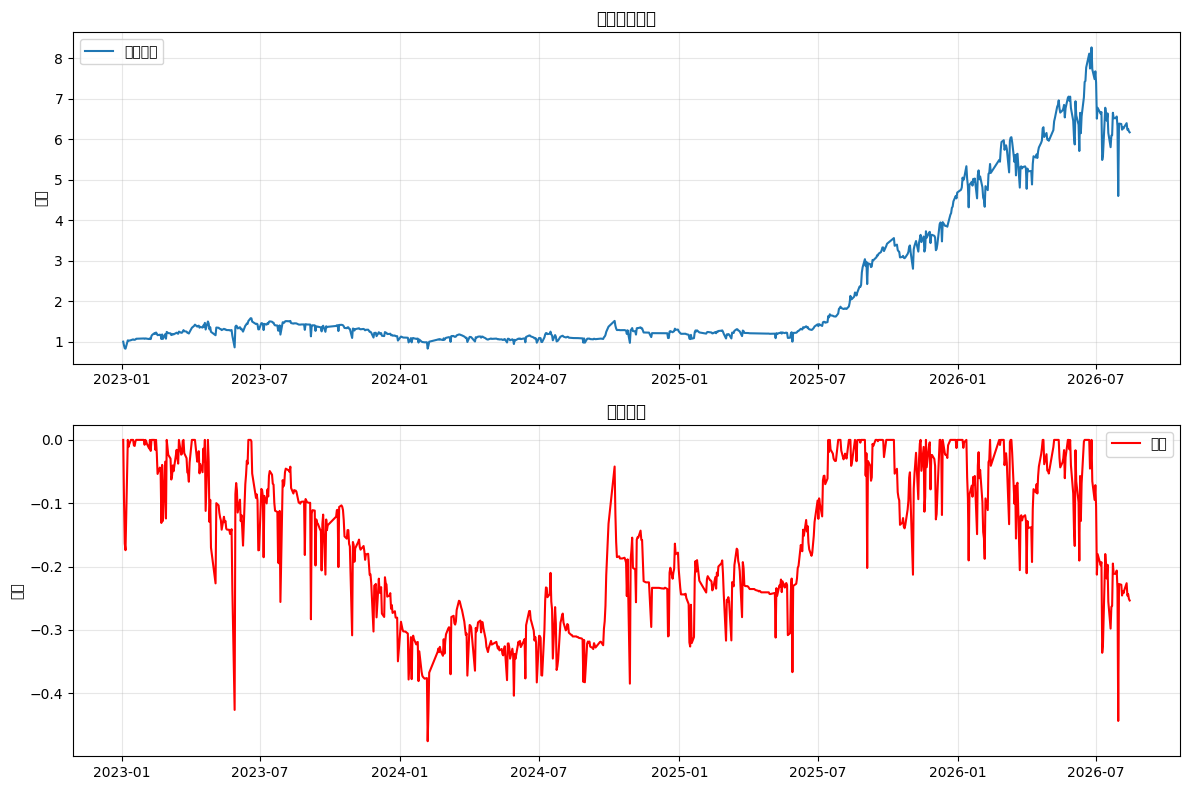

In [6]:
# 绘制净值曲线
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# 净值曲线
axes[0].plot(nav_history.index, nav_history['nav'] / nav_history['nav'].iloc[0], label='策略净值')
axes[0].set_title('策略净值曲线')
axes[0].set_ylabel('净值')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# 回撤曲线
rolling_max = nav_history['nav'].cummax()
drawdowns = nav_history['nav'] / rolling_max - 1
axes[1].plot(nav_history.index, drawdowns, label='回撤', color='red')
axes[1].set_title('回撤曲线')
axes[1].set_ylabel('回撤')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. 交易分析

In [7]:
# 交易统计
trades = strategy.portfolio.trade_log
if trades:
    trades_df = pd.DataFrame(trades)
    print(f'总交易次数: {len(trades_df)}')
    print(f'买入次数: {len(trades_df[trades_df["action"] == "buy"])}')
    print(f'卖出次数: {len(trades_df[trades_df["action"] == "sell"])}')
    
    # 计算胜率
    buy_trades = trades_df[trades_df['action'] == 'buy']
    sell_trades = trades_df[trades_df['action'] == 'sell']
    
    # 按股票分组计算盈亏
    if len(sell_trades) > 0:
        # 合并买入和卖出交易
        profit_analysis = []
        for code in sell_trades['code'].unique():
            stock_buys = buy_trades[buy_trades['code'] == code]
            stock_sells = sell_trades[sell_trades['code'] == code]
            
            for _, sell in stock_sells.iterrows():
                # 找到对应的买入交易
                matching_buys = stock_buys[stock_buys['date'] <= sell['date']]
                if len(matching_buys) > 0:
                    avg_buy_price = matching_buys['price'].mean()
                    profit_pct = (sell['price'] - avg_buy_price) / avg_buy_price
                    profit_analysis.append({
                        'code': code,
                        'sell_date': sell['date'],
                        'buy_price': avg_buy_price,
                        'sell_price': sell['price'],
                        'profit_pct': profit_pct,
                    })
        
        if profit_analysis:
            profit_df = pd.DataFrame(profit_analysis)
            win_rate = len(profit_df[profit_df['profit_pct'] > 0]) / len(profit_df)
            avg_profit = profit_df['profit_pct'].mean()
            avg_loss = profit_df[profit_df['profit_pct'] < 0]['profit_pct'].mean() if len(profit_df[profit_df['profit_pct'] < 0]) > 0 else 0
            profit_loss_ratio = abs(avg_profit / avg_loss) if avg_loss != 0 else float('inf')
            
            print(f'\n交易分析:')
            print(f'  胜率: {win_rate:.2%}')
            print(f'  平均盈利: {avg_profit:.2%}')
            print(f'  平均亏损: {avg_loss:.2%}')
            print(f'  盈亏比: {profit_loss_ratio:.2f}')
    
    # 显示前10笔交易
    print('\n前10笔交易:')
    print(trades_df.head(10).to_string())
else:
    print('没有交易记录')

总交易次数: 819
买入次数: 472
卖出次数: 347

交易分析:
  胜率: 70.03%
  平均盈利: 46.83%
  平均亏损: -9.39%
  盈亏比: 4.99

前10笔交易:
        date    code action  price  shares       amount  reason
0 2023-01-03  300274    buy  79.56    1200   95500.6416  signal
1 2023-01-03  000938    buy  20.14    4900   98715.6058  signal
2 2023-01-04  300394    buy   9.49   10600  100624.1782  signal
3 2023-01-04  603259    buy  76.38    1300   99323.7882  signal
4 2023-01-04  601318    buy  40.53    2400   97301.1816  signal
5 2023-01-04  000938    buy  22.15    4500   99704.9025  signal
6 2023-01-05  000938    buy  24.37    4200  102384.7062  signal
7 2023-01-05  603259    buy  81.34    1200   97637.2824  signal
8 2023-01-06  300274    buy  82.66    1200   99221.7576  signal
9 2023-01-06  601318    buy  41.54    2400   99725.9088  signal


In [8]:
# 持仓分析
if strategy.portfolio.holdings:
    print('当前持仓:')
    for code, holding in strategy.portfolio.holdings.items():
        stock_name = holding.name if holding.name else f'股票{code}'
        print(f'  {code} {stock_name}: {holding.shares:.0f} 股, '
              f'平均成本: {holding.avg_cost:.2f}, '
              f'当前价: {holding.current_price:.2f}, '
              f'市值: {holding.market_value:,.0f}')
else:
    print('当前没有持仓')

当前持仓:
  600519 贵州茅台: 1300 股, 平均成本: 1308.64, 当前价: 1341.99, 市值: 1,744,587
  300058 蓝色光标: 28200 股, 平均成本: 15.72, 当前价: 15.10, 市值: 425,820
  603259 药明康德: 4000 股, 平均成本: 154.82, 当前价: 159.24, 市值: 636,960
  300394 天孚通信: 1300 股, 平均成本: 257.16, 当前价: 267.71, 市值: 348,023


## 5. 持仓股票价格走势图

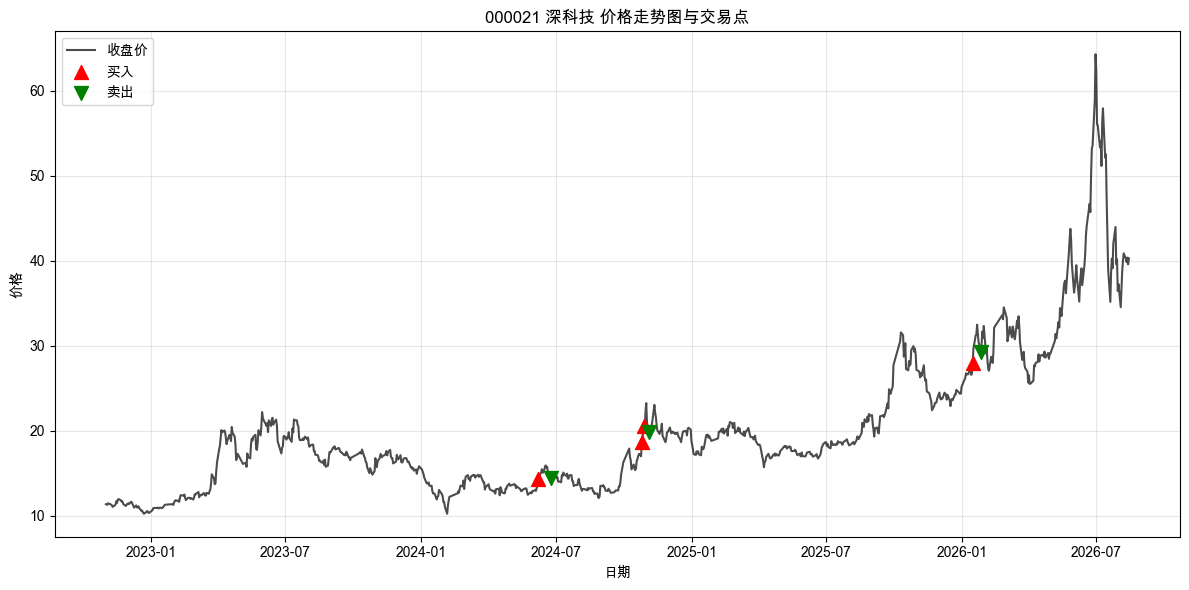


000021 深科技 交易统计:
  买入次数: 4
  卖出次数: 3
  平均买入价: 20.38
  平均卖出价: 21.19


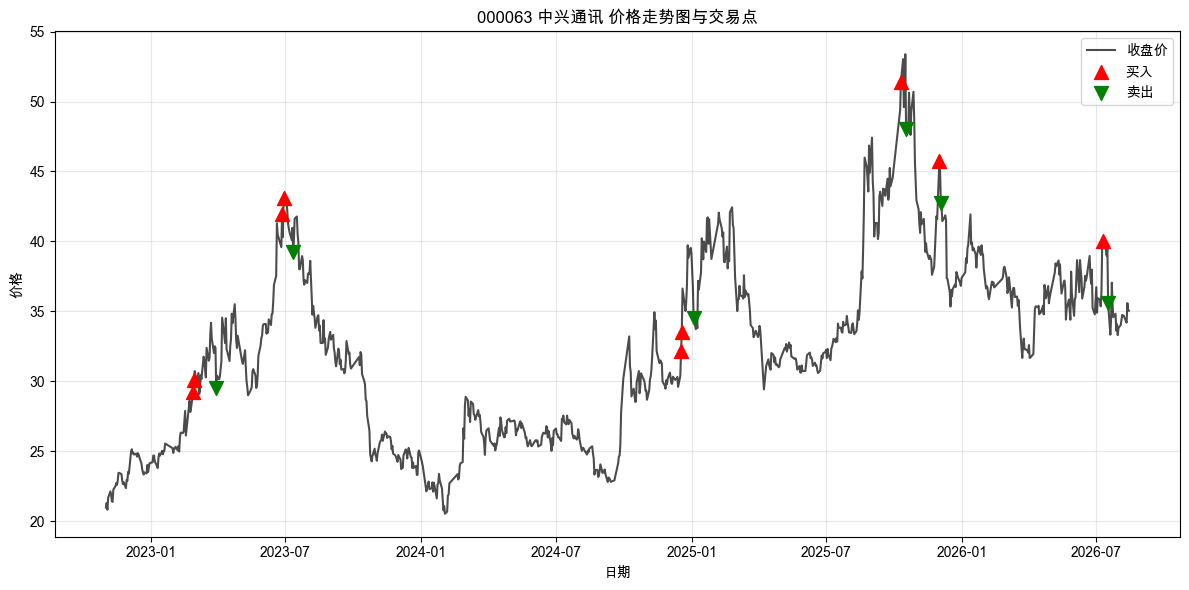


000063 中兴通讯 交易统计:
  买入次数: 9
  卖出次数: 6
  平均买入价: 38.58
  平均卖出价: 38.29


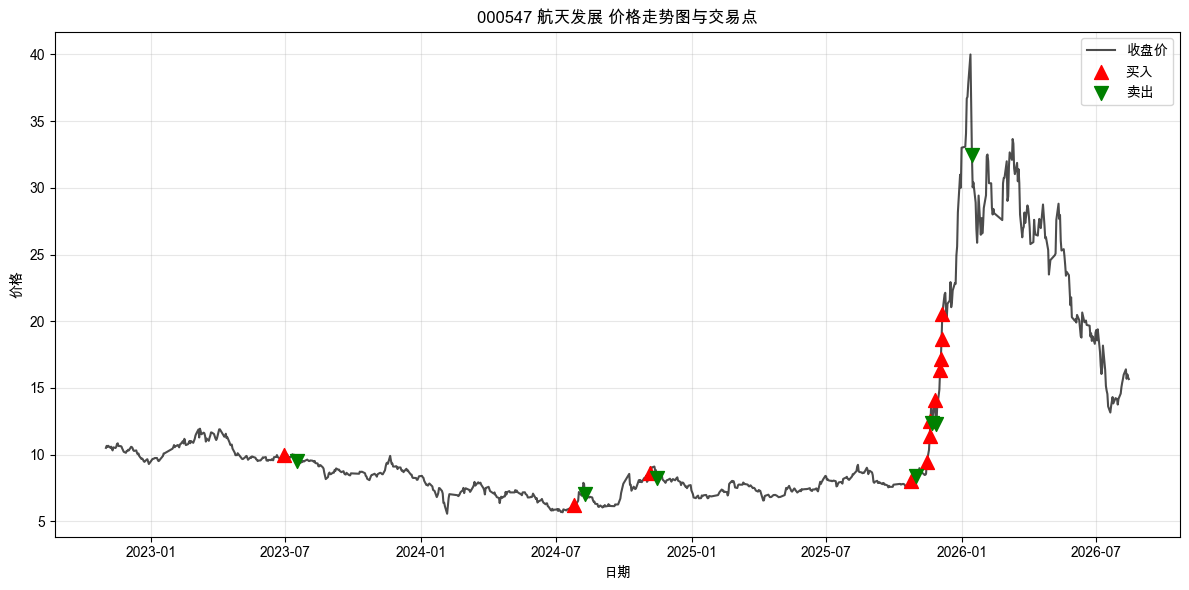


000547 航天发展 交易统计:
  买入次数: 12
  卖出次数: 7
  平均买入价: 12.75
  平均卖出价: 12.90


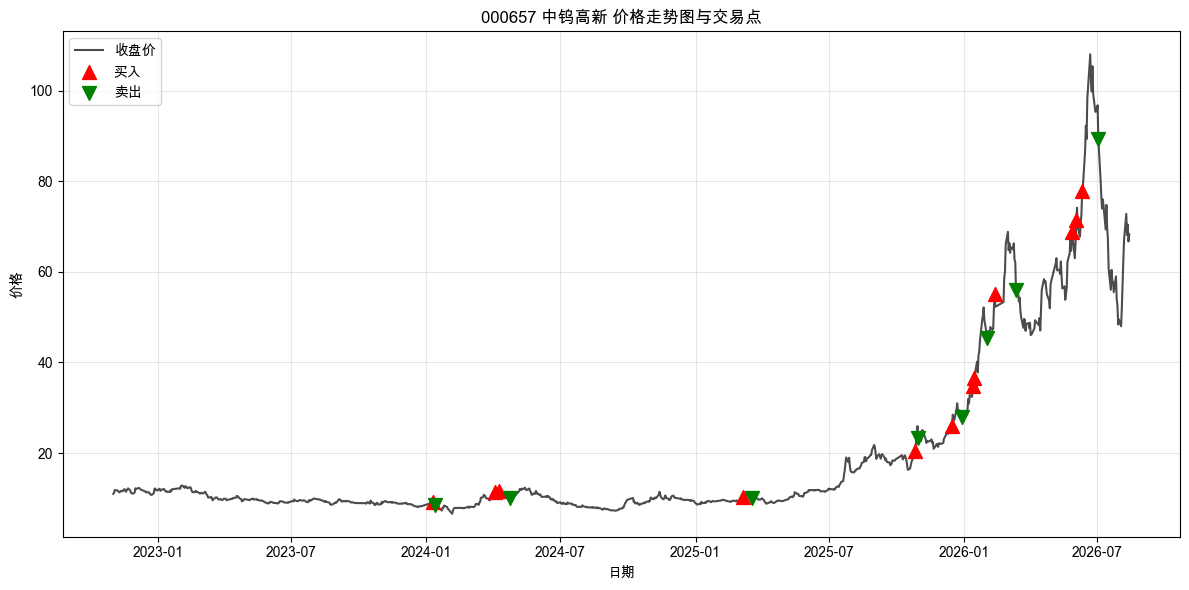


000657 中钨高新 交易统计:
  买入次数: 12
  卖出次数: 8
  平均买入价: 36.11
  平均卖出价: 33.87


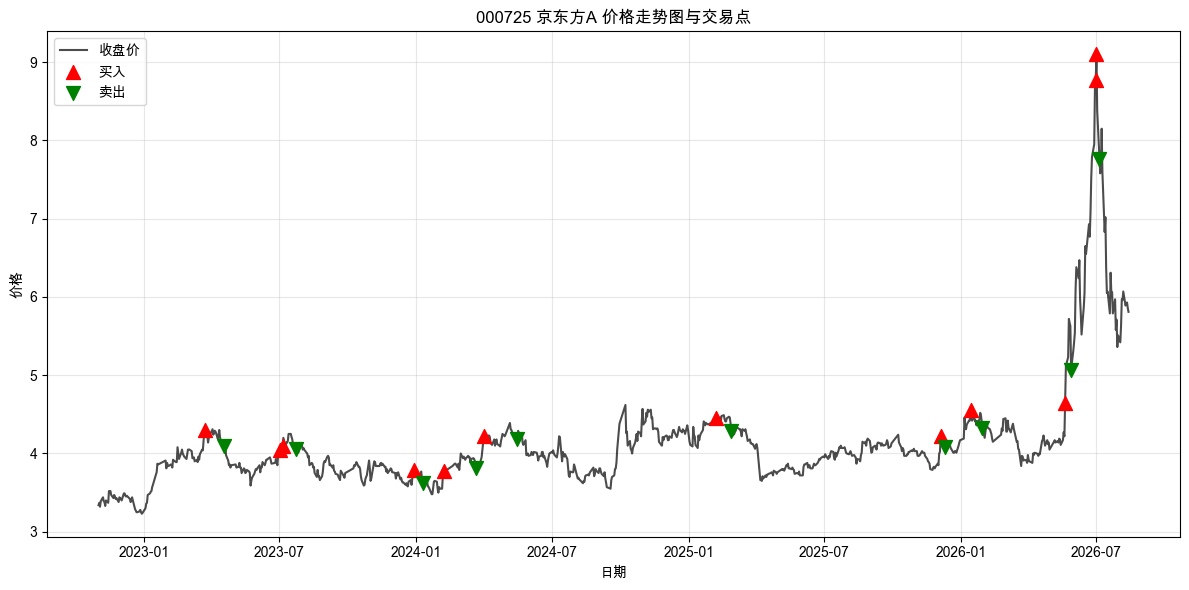


000725 京东方A 交易统计:
  买入次数: 12
  卖出次数: 10
  平均买入价: 5.00
  平均卖出价: 4.53


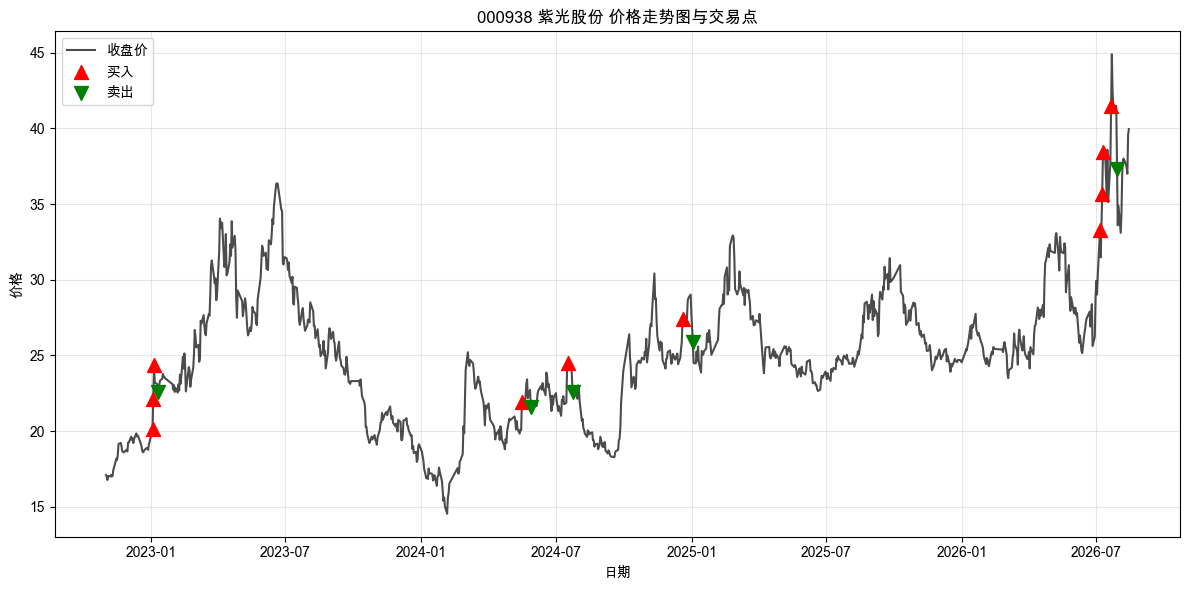


000938 紫光股份 交易统计:
  买入次数: 10
  卖出次数: 5
  平均买入价: 28.94
  平均卖出价: 26.01


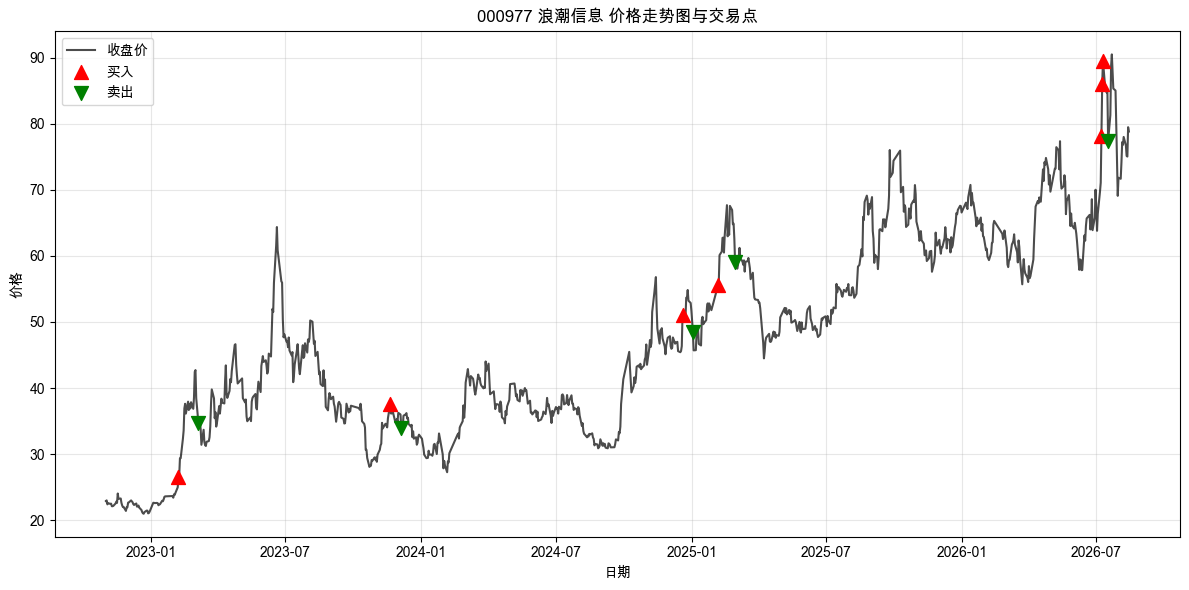


000977 浪潮信息 交易统计:
  买入次数: 7
  卖出次数: 5
  平均买入价: 60.62
  平均卖出价: 50.72


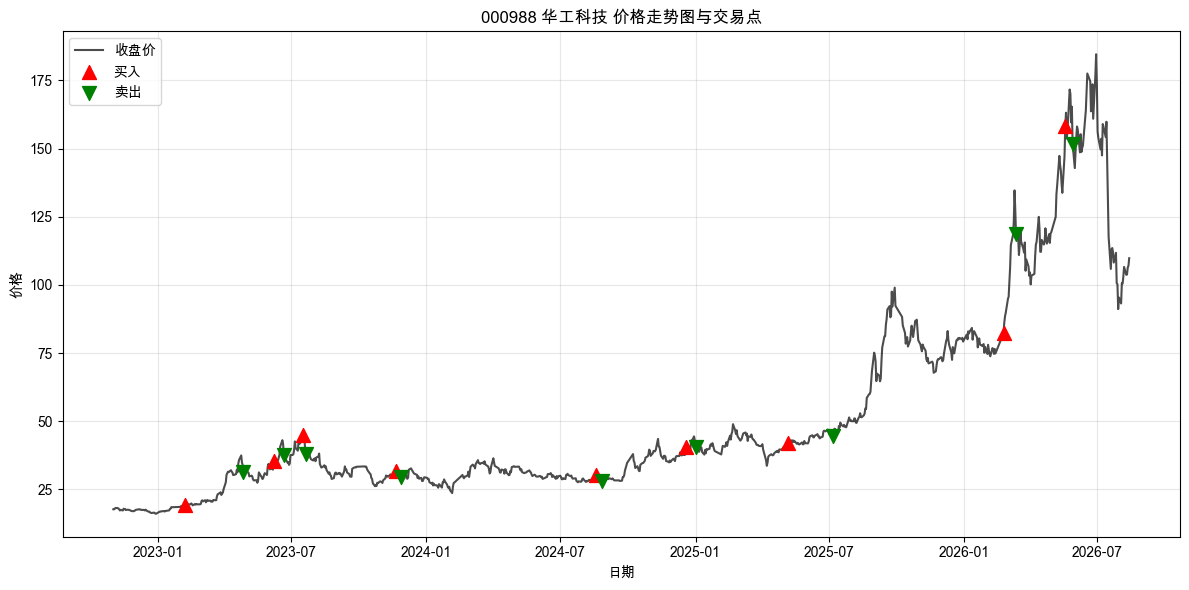


000988 华工科技 交易统计:
  买入次数: 9
  卖出次数: 9
  平均买入价: 53.81
  平均卖出价: 57.74


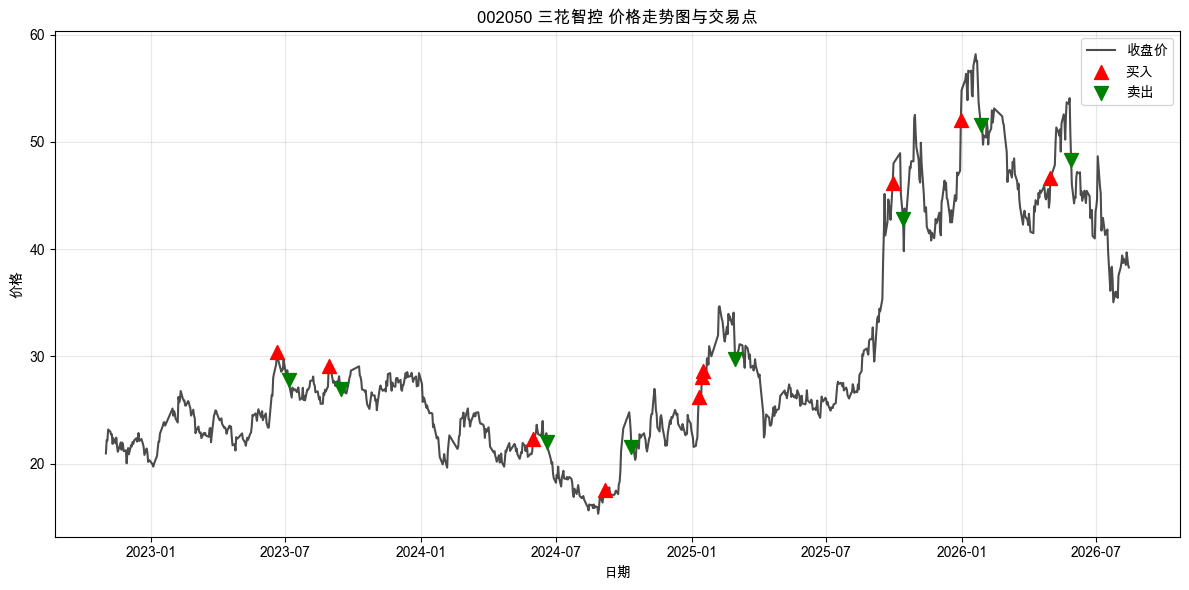


002050 三花智控 交易统计:
  买入次数: 10
  卖出次数: 8
  平均买入价: 32.71
  平均卖出价: 33.85


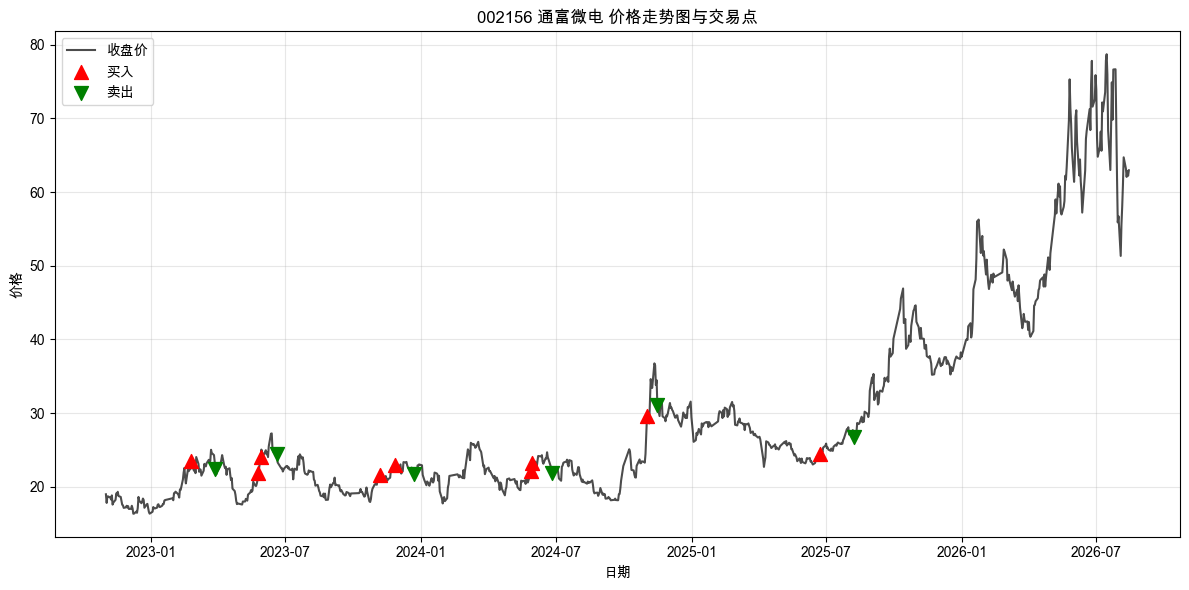


002156 通富微电 交易统计:
  买入次数: 9
  卖出次数: 6
  平均买入价: 23.72
  平均卖出价: 24.71


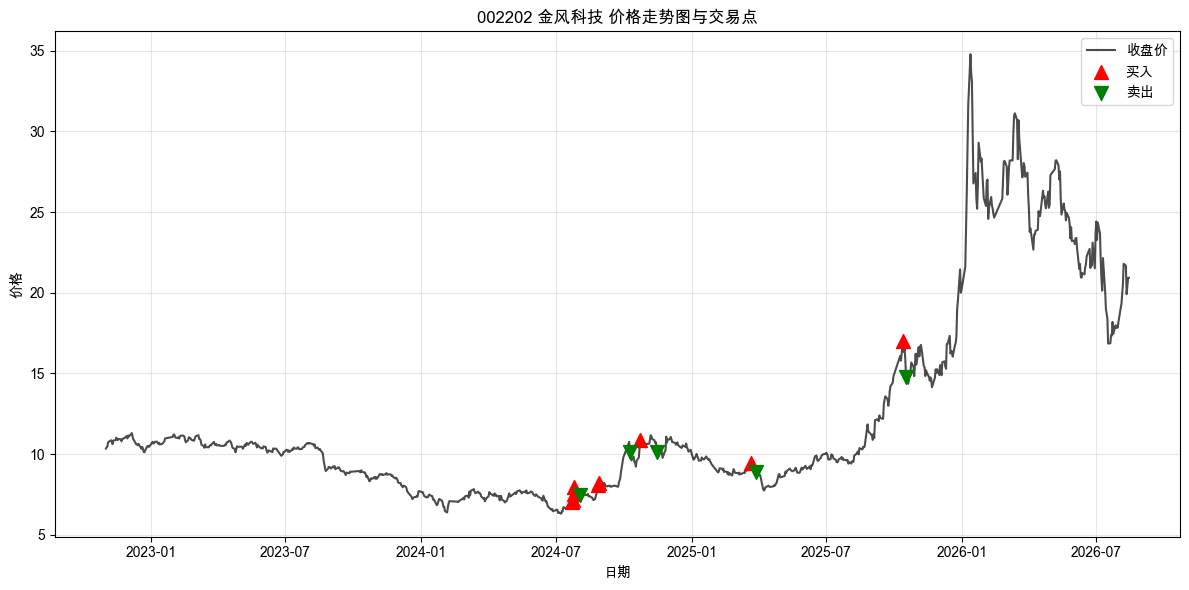


002202 金风科技 交易统计:
  买入次数: 9
  卖出次数: 5
  平均买入价: 9.25
  平均卖出价: 10.28


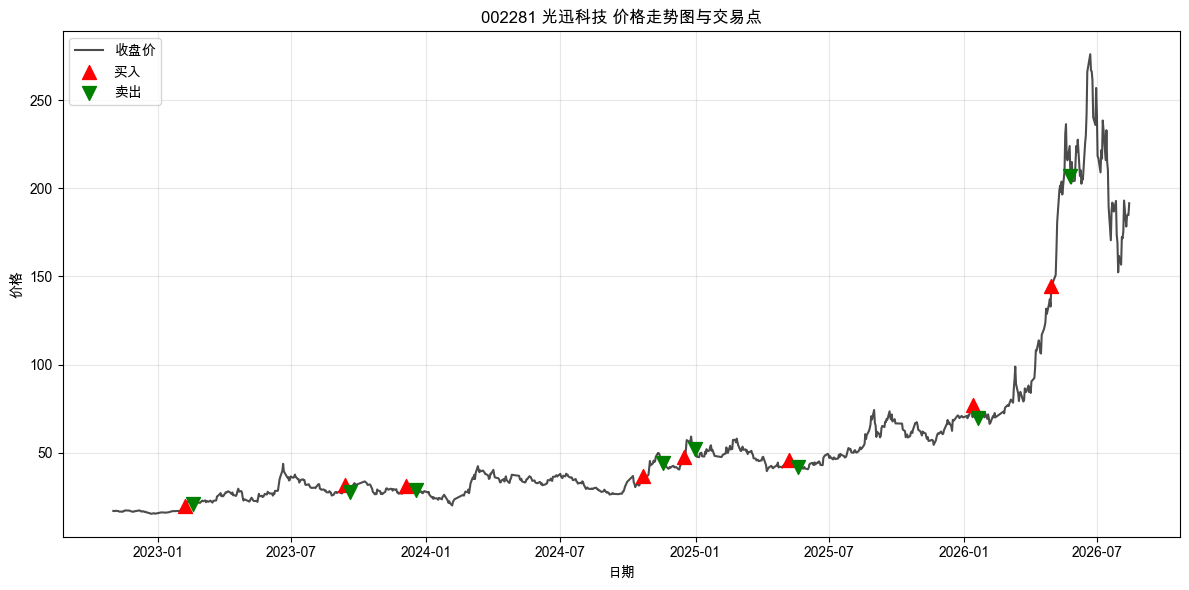


002281 光迅科技 交易统计:
  买入次数: 8
  卖出次数: 8
  平均买入价: 54.19
  平均卖出价: 61.41


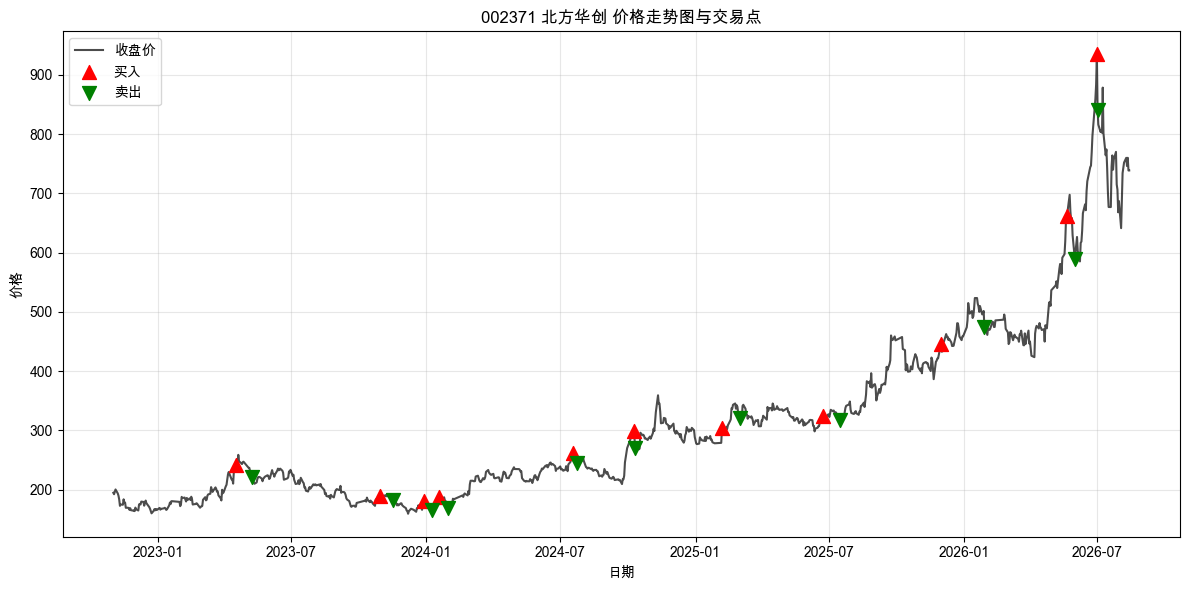


002371 北方华创 交易统计:
  买入次数: 11
  卖出次数: 11
  平均买入价: 366.63
  平均卖出价: 345.48


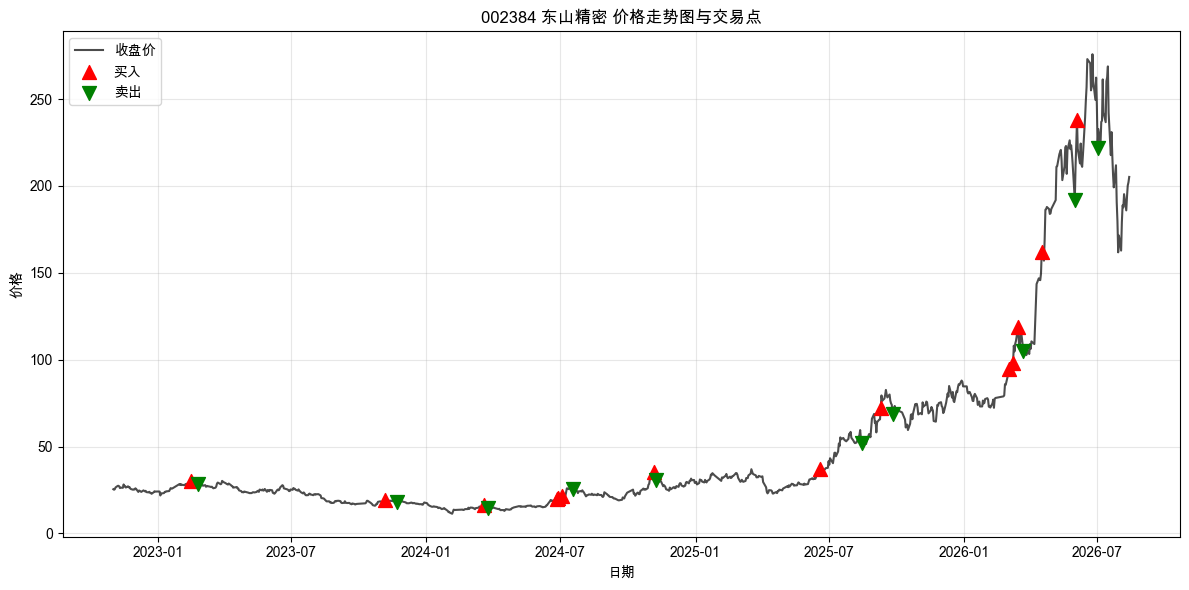


002384 东山精密 交易统计:
  买入次数: 14
  卖出次数: 10
  平均买入价: 70.32
  平均卖出价: 75.71


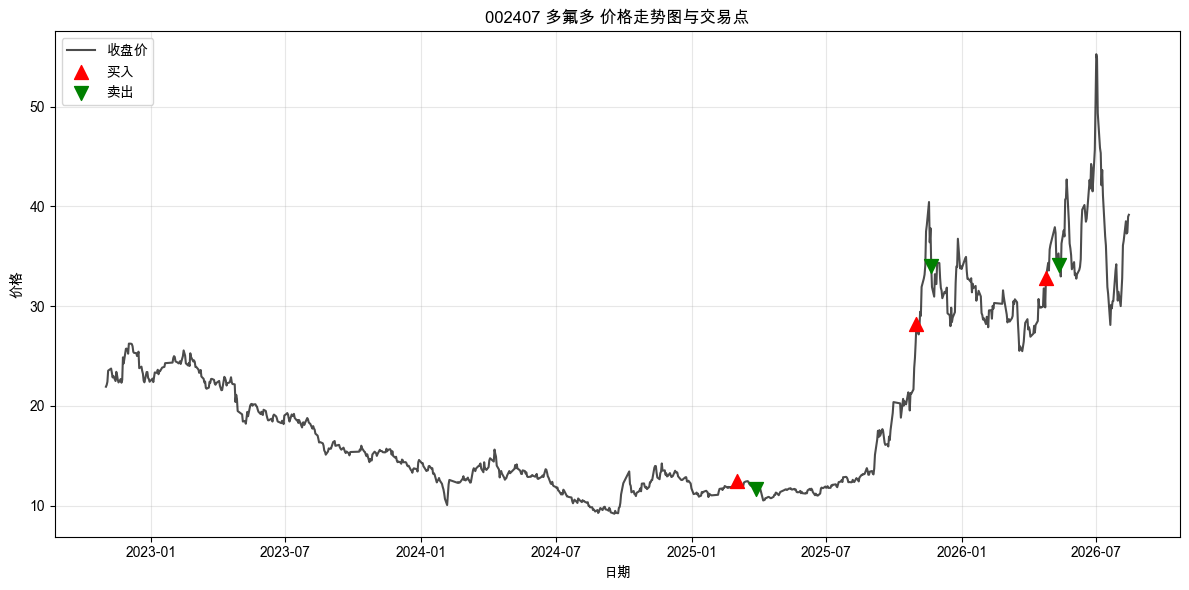


002407 多氟多 交易统计:
  买入次数: 3
  卖出次数: 3
  平均买入价: 24.54
  平均卖出价: 26.64


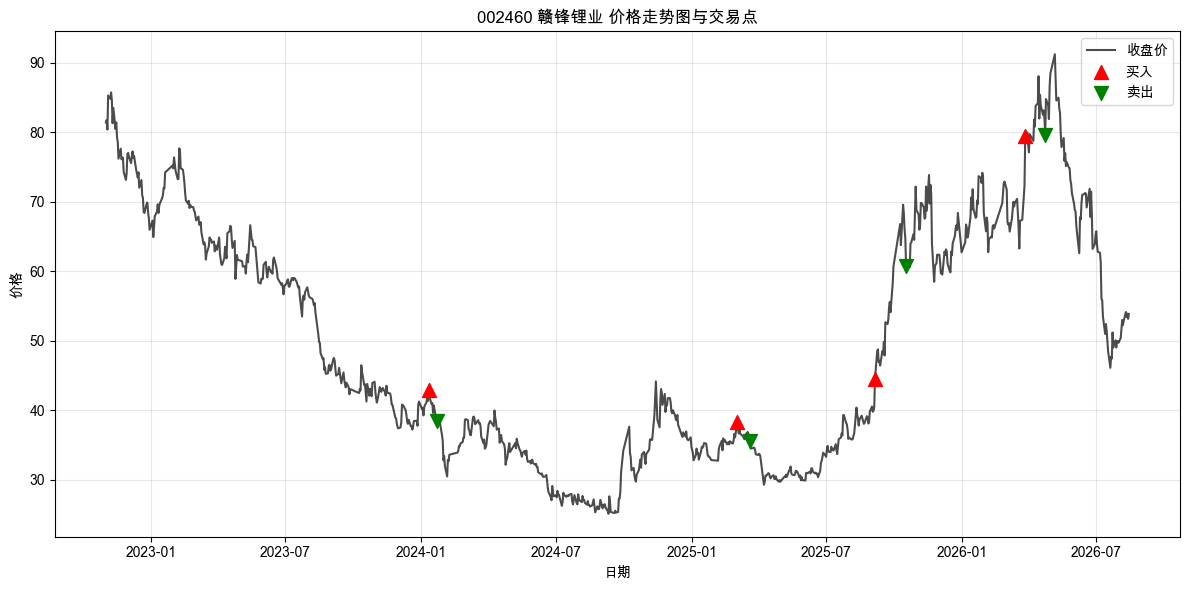


002460 赣锋锂业 交易统计:
  买入次数: 4
  卖出次数: 4
  平均买入价: 51.29
  平均卖出价: 53.62


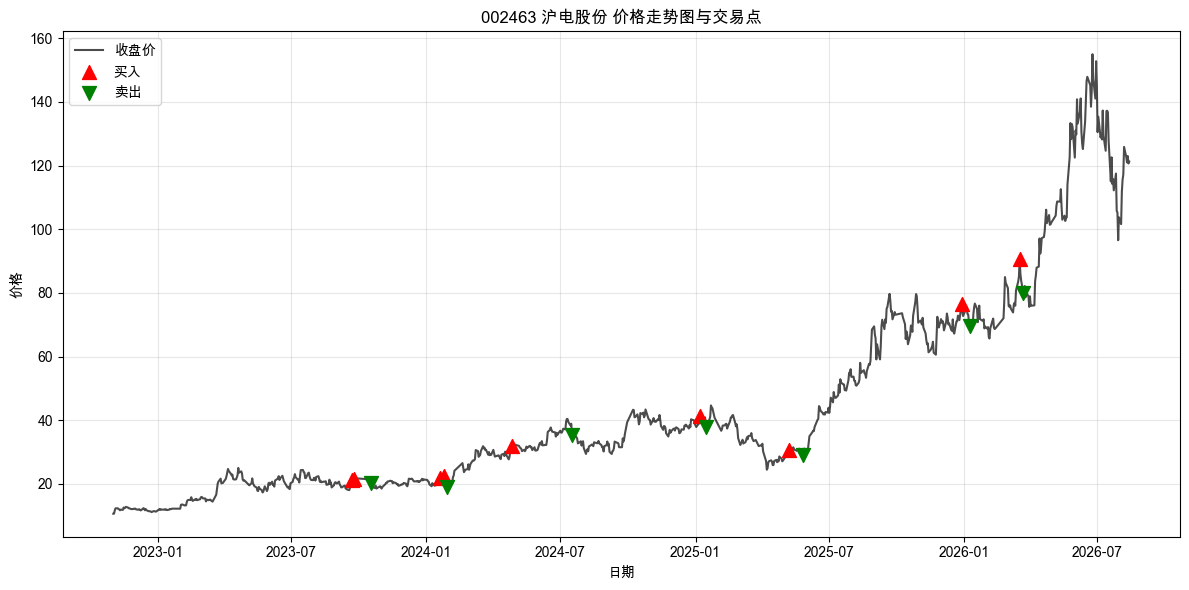


002463 沪电股份 交易统计:
  买入次数: 9
  卖出次数: 7
  平均买入价: 39.78
  平均卖出价: 41.59


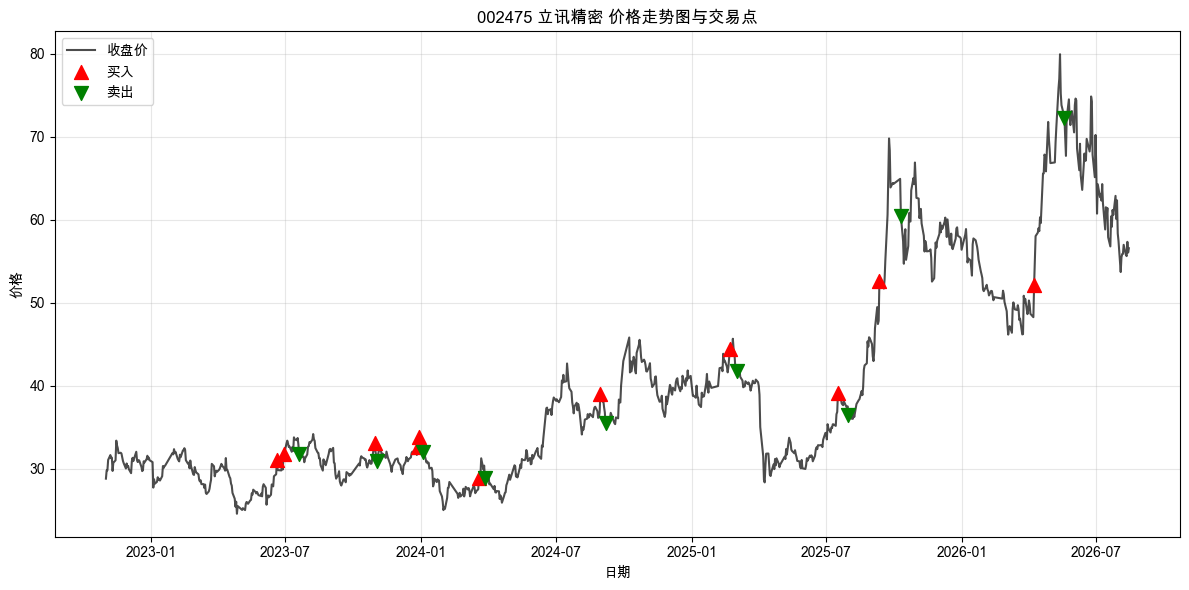


002475 立讯精密 交易统计:
  买入次数: 11
  卖出次数: 9
  平均买入价: 38.06
  平均卖出价: 41.13


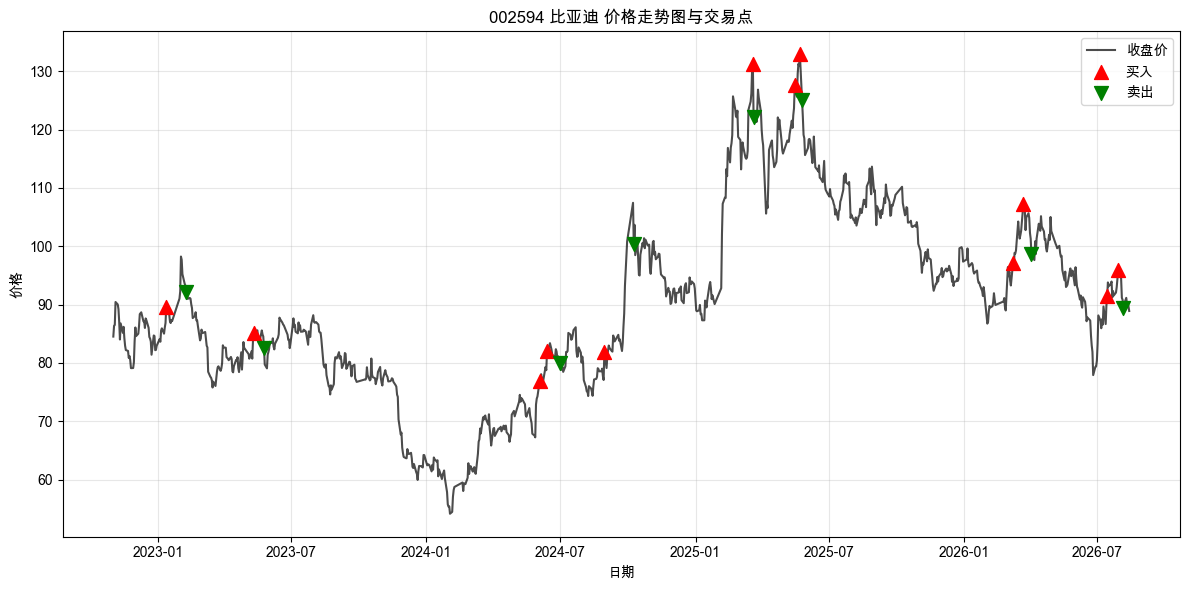


002594 比亚迪 交易统计:
  买入次数: 12
  卖出次数: 8
  平均买入价: 99.91
  平均卖出价: 98.78


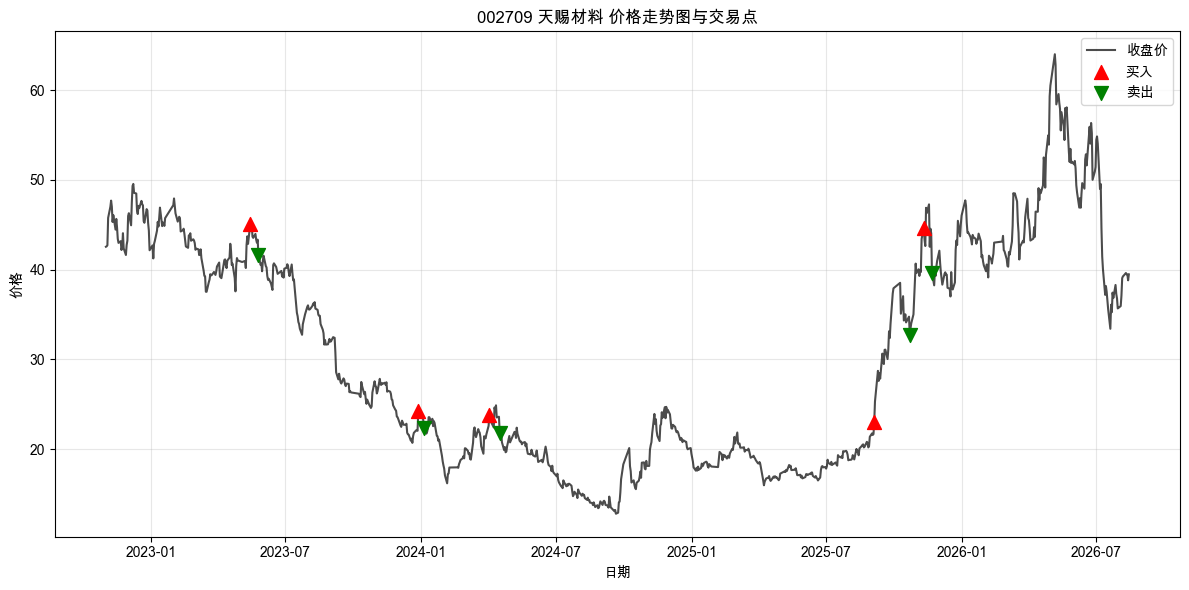


002709 天赐材料 交易统计:
  买入次数: 5
  卖出次数: 5
  平均买入价: 32.16
  平均卖出价: 31.64


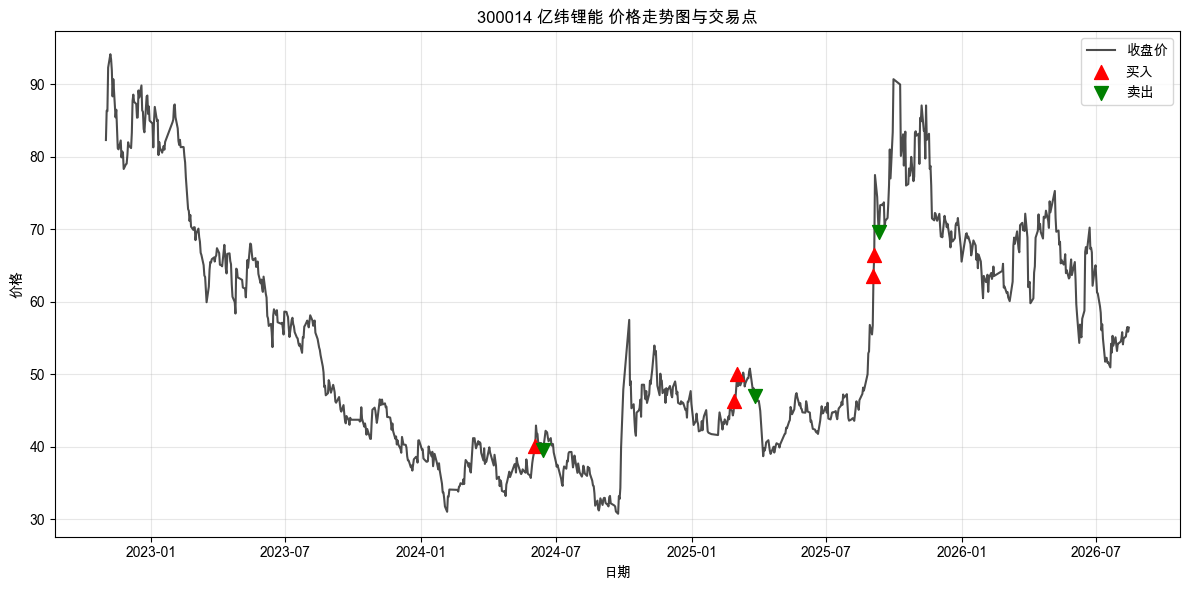


300014 亿纬锂能 交易统计:
  买入次数: 5
  卖出次数: 3
  平均买入价: 53.30
  平均卖出价: 52.12


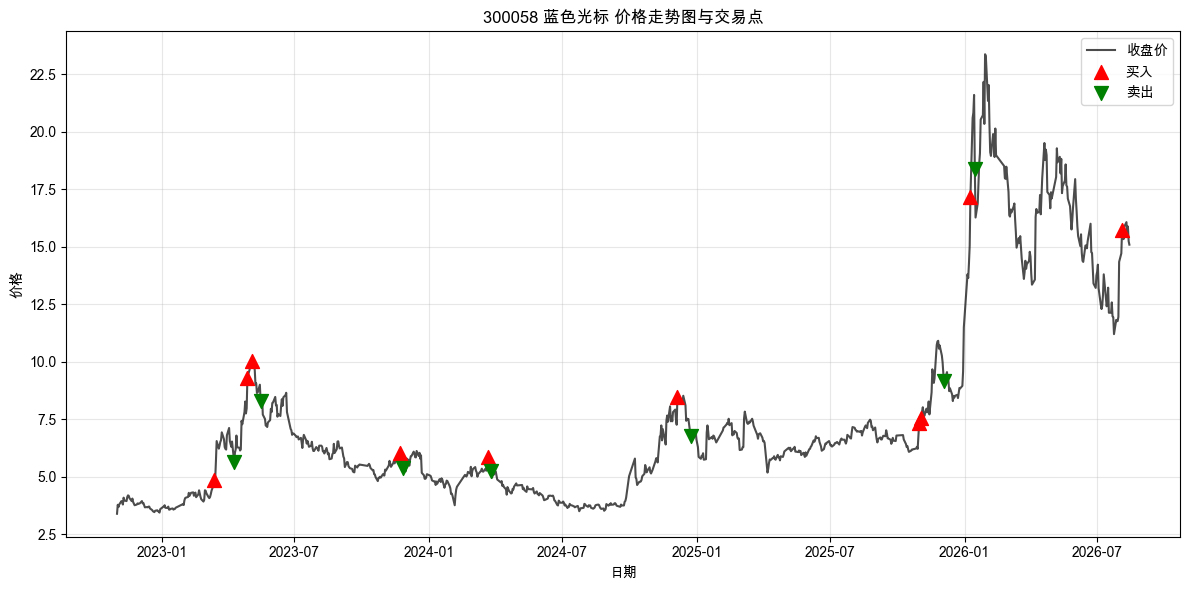


300058 蓝色光标 交易统计:
  买入次数: 10
  卖出次数: 7
  平均买入价: 9.24
  平均卖出价: 8.42


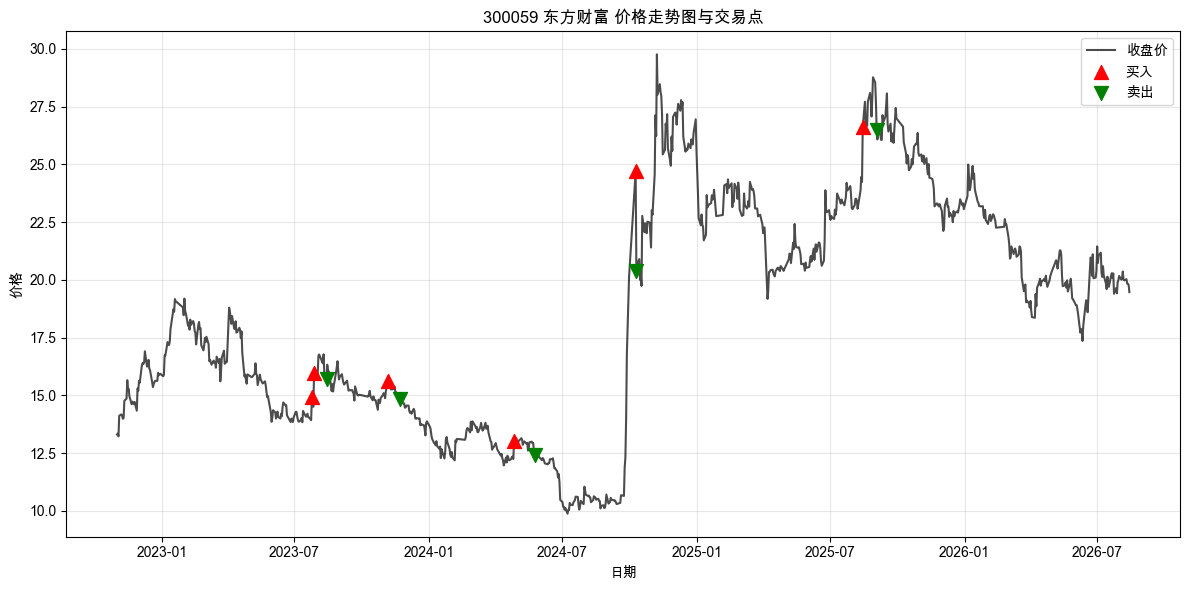


300059 东方财富 交易统计:
  买入次数: 6
  卖出次数: 5
  平均买入价: 18.47
  平均卖出价: 17.97


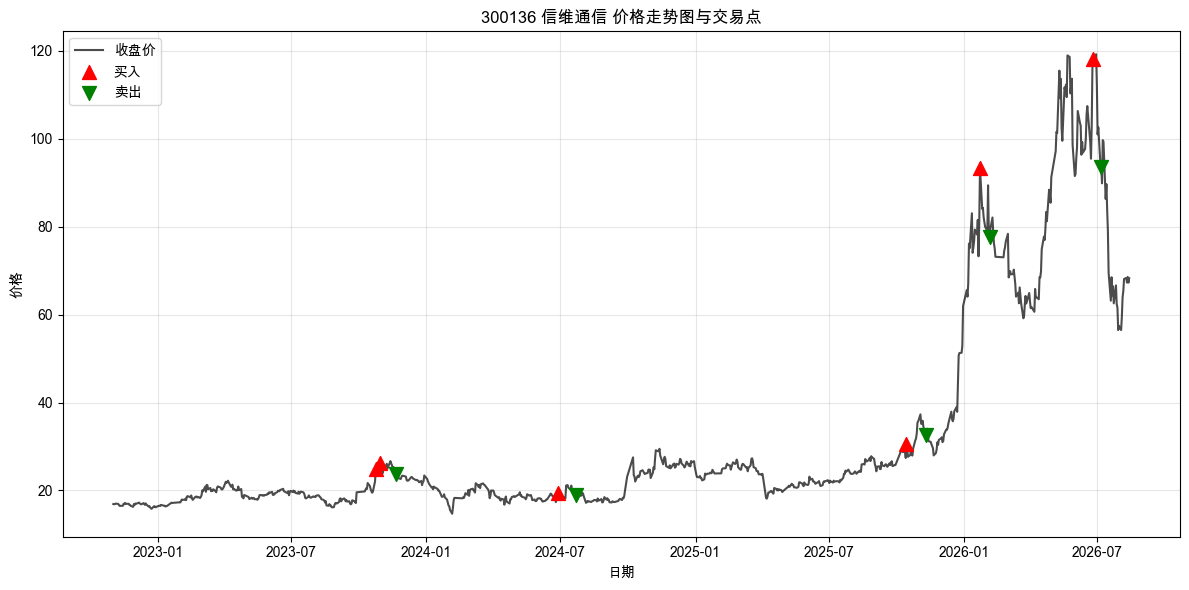


300136 信维通信 交易统计:
  买入次数: 6
  卖出次数: 5
  平均买入价: 52.13
  平均卖出价: 49.39


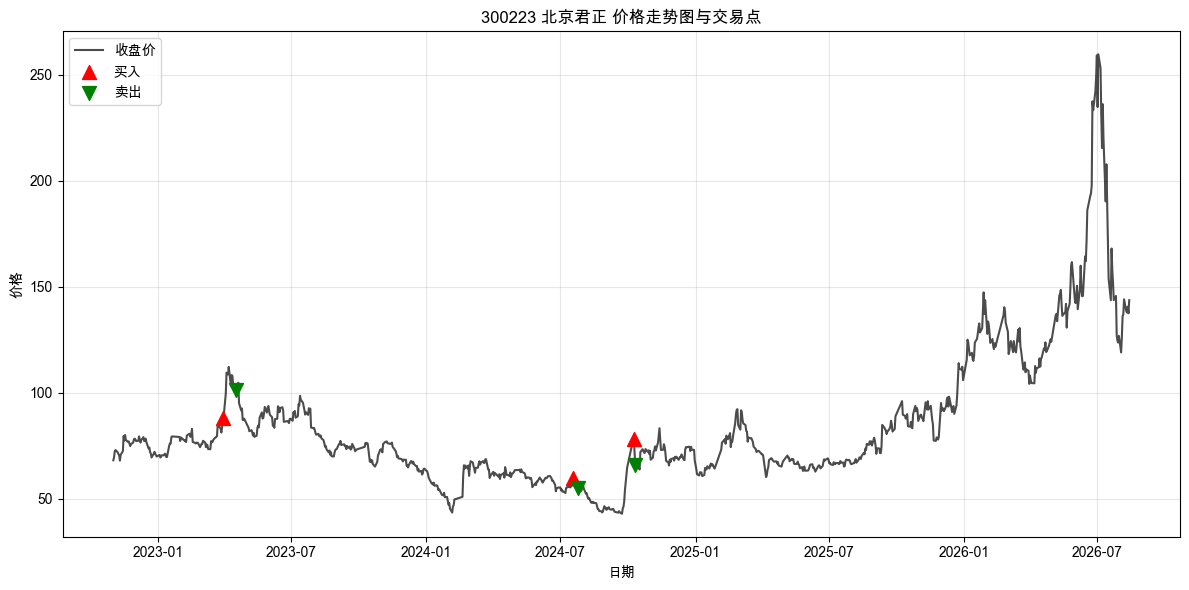


300223 北京君正 交易统计:
  买入次数: 3
  卖出次数: 3
  平均买入价: 75.51
  平均卖出价: 74.09


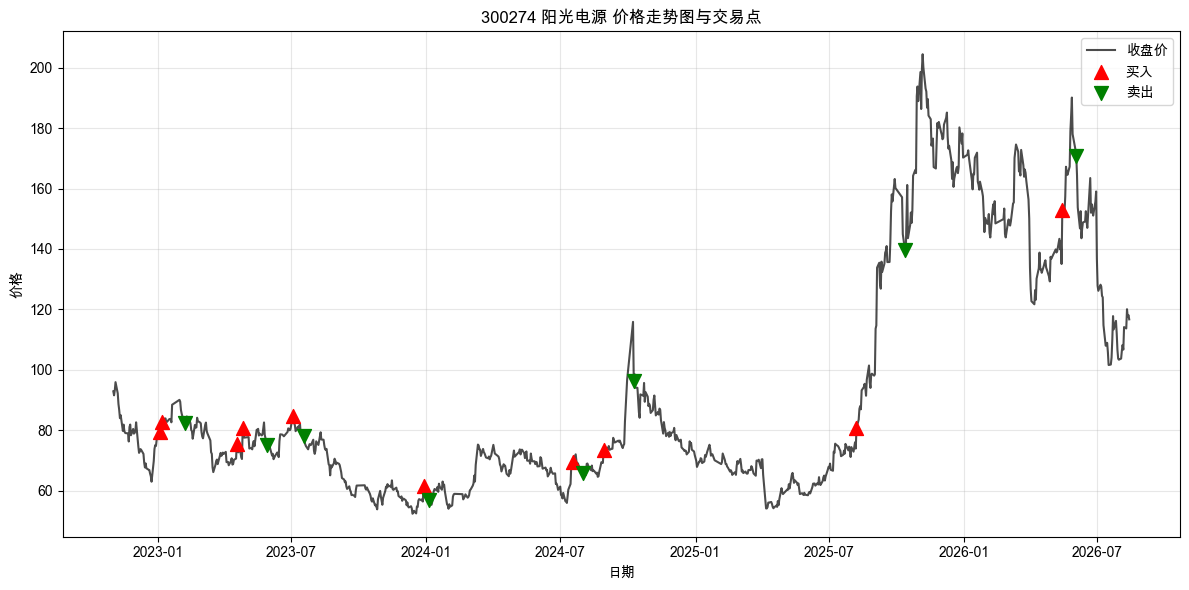


300274 阳光电源 交易统计:
  买入次数: 10
  卖出次数: 8
  平均买入价: 84.17
  平均卖出价: 95.71


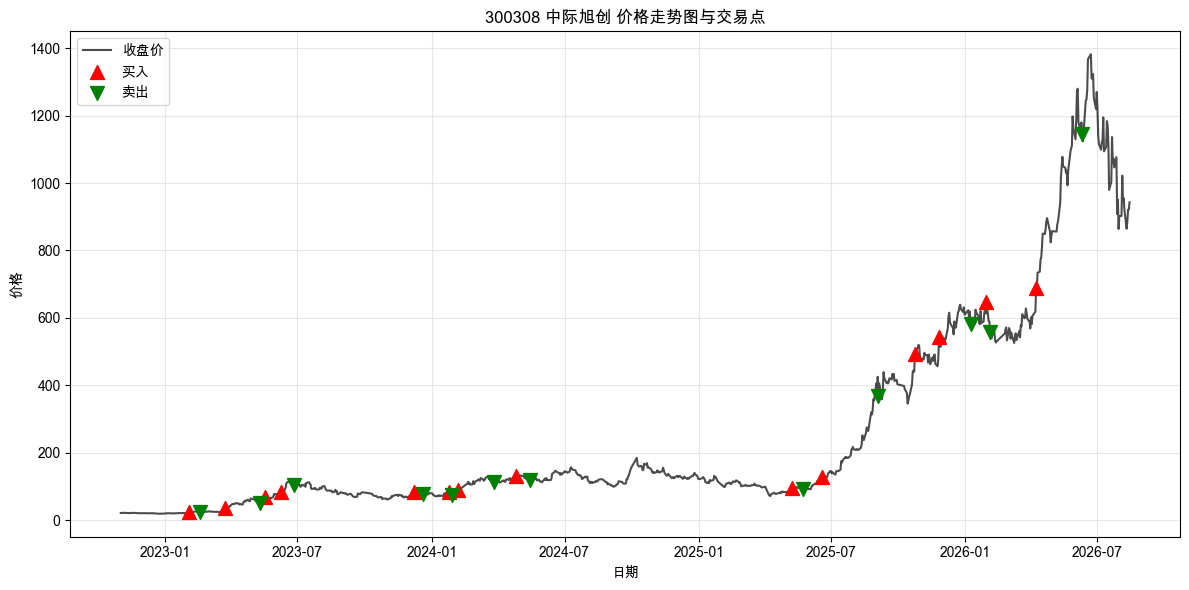


300308 中际旭创 交易统计:
  买入次数: 14
  卖出次数: 12
  平均买入价: 228.07
  平均卖出价: 275.97


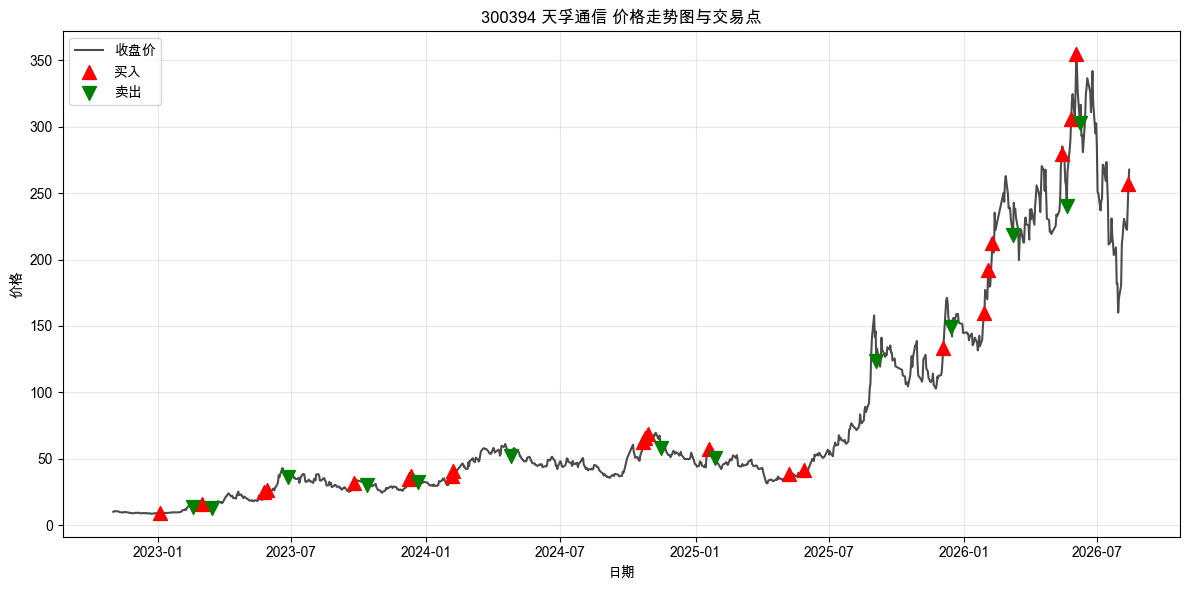


300394 天孚通信 交易统计:
  买入次数: 23
  卖出次数: 13
  平均买入价: 108.11
  平均卖出价: 101.70


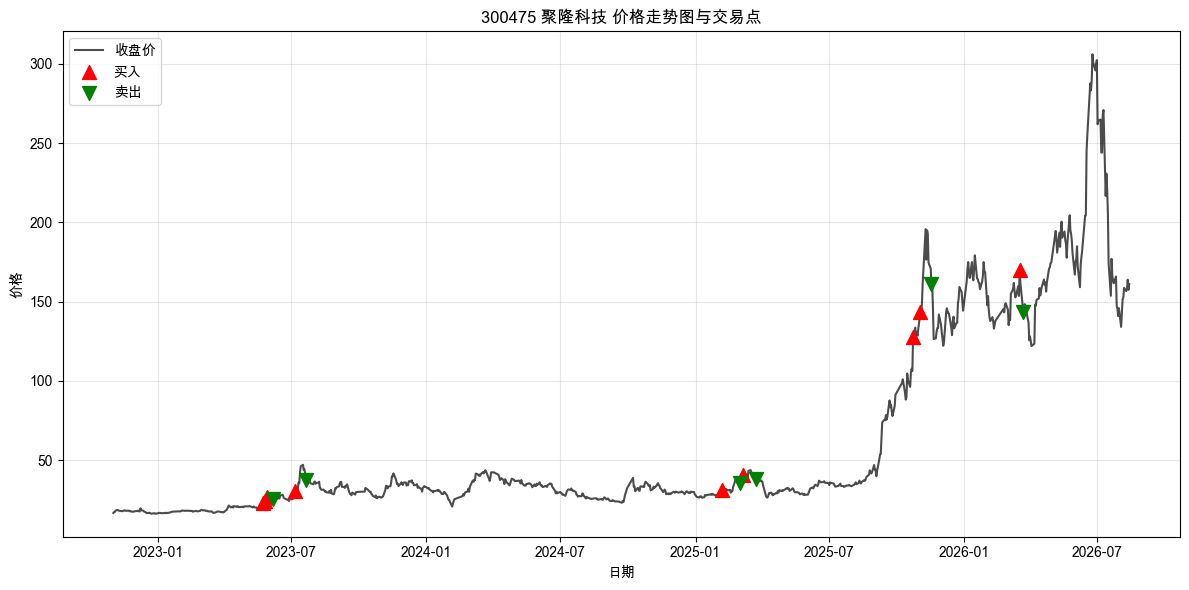


300475 聚隆科技 交易统计:
  买入次数: 9
  卖出次数: 6
  平均买入价: 68.60
  平均卖出价: 73.41


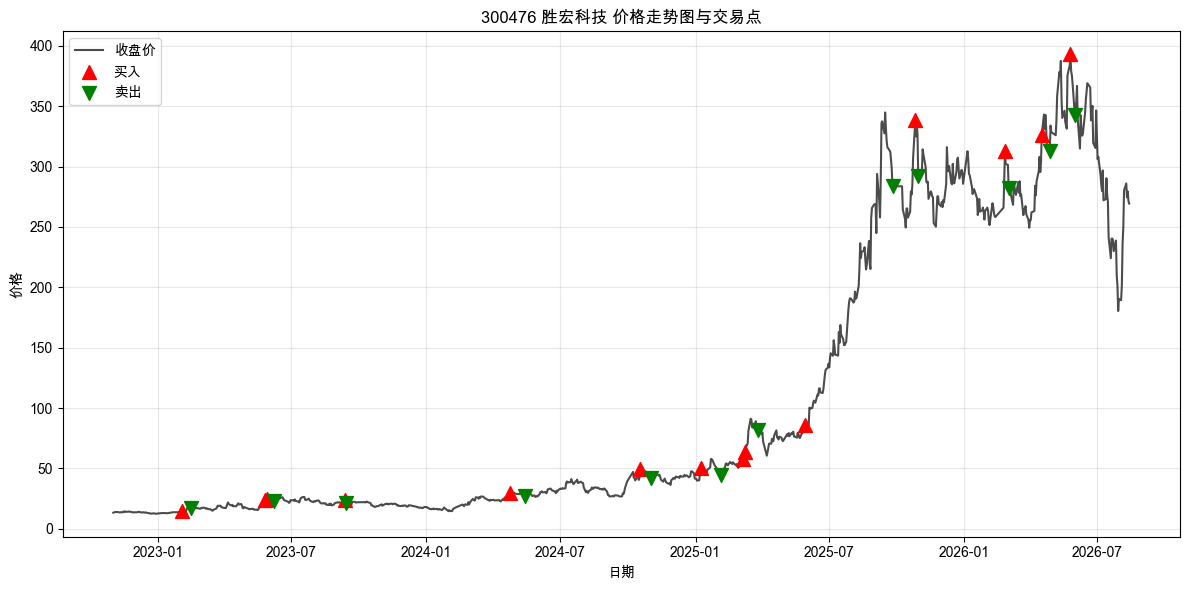


300476 胜宏科技 交易统计:
  买入次数: 14
  卖出次数: 12
  平均买入价: 128.17
  平均卖出价: 147.60


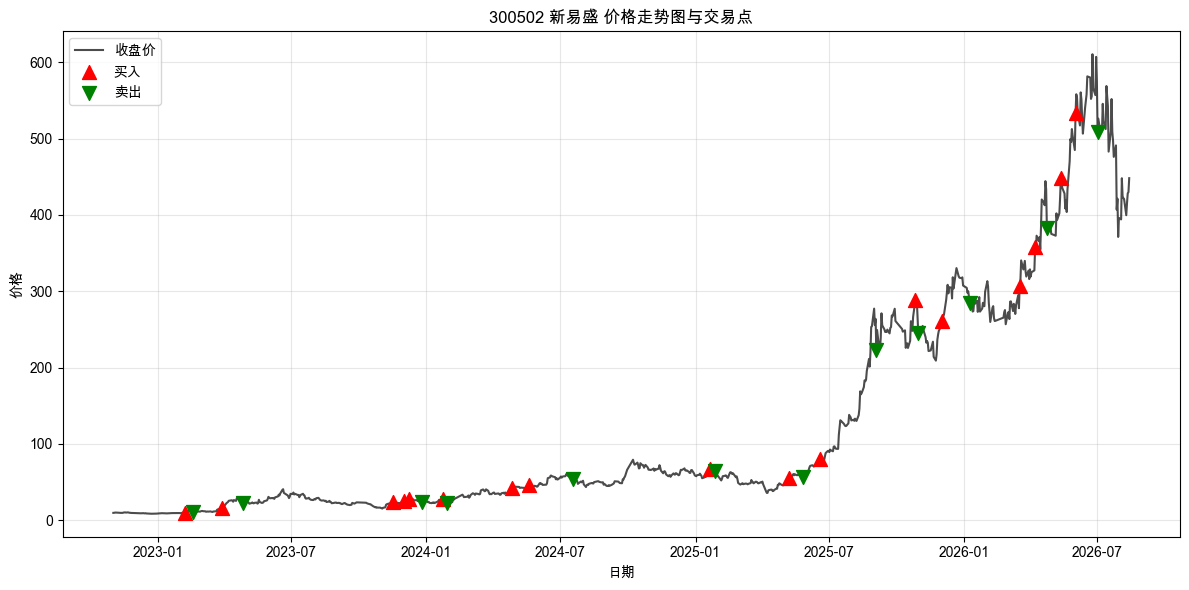


300502 新易盛 交易统计:
  买入次数: 17
  卖出次数: 12
  平均买入价: 153.93
  平均卖出价: 158.28


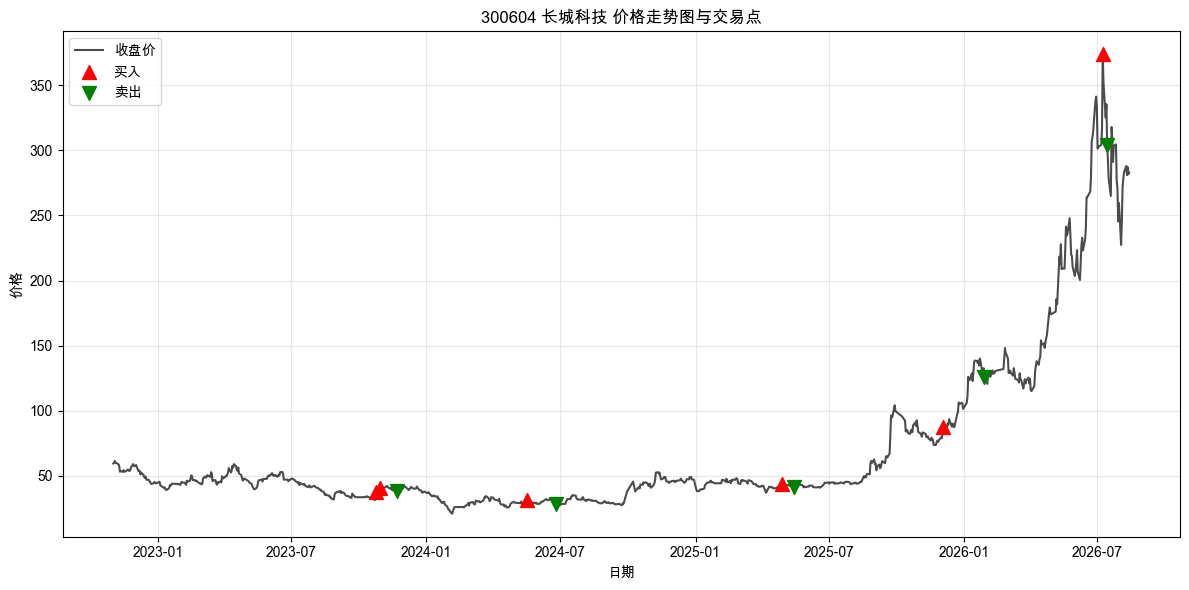


300604 长城科技 交易统计:
  买入次数: 6
  卖出次数: 5
  平均买入价: 102.36
  平均卖出价: 107.58


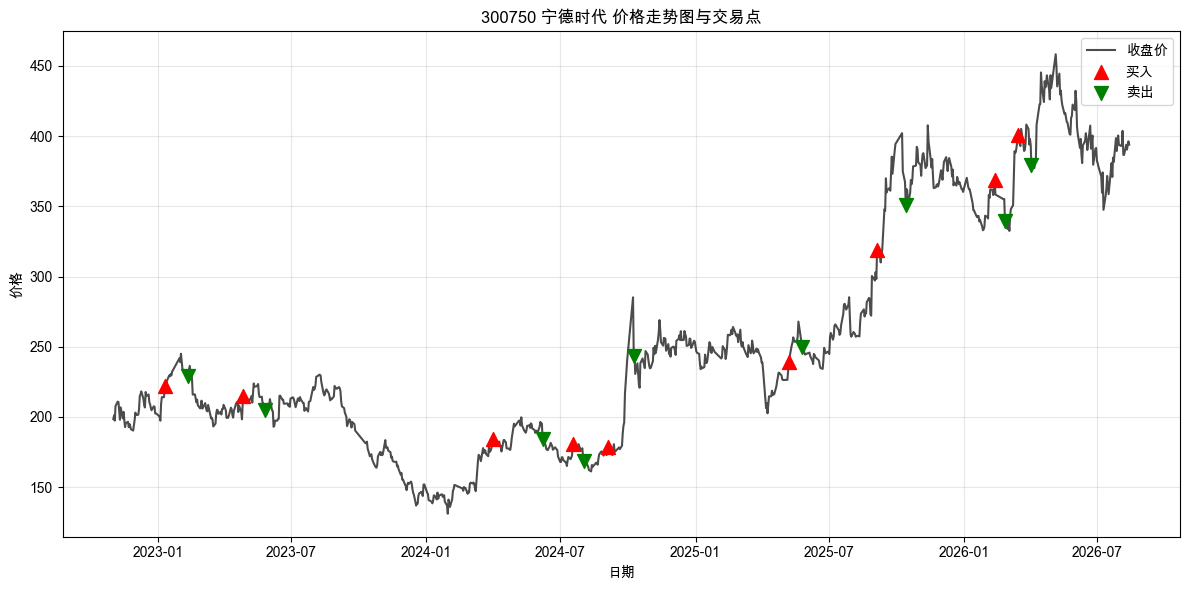


300750 宁德时代 交易统计:
  买入次数: 9
  卖出次数: 9
  平均买入价: 256.42
  平均卖出价: 261.13


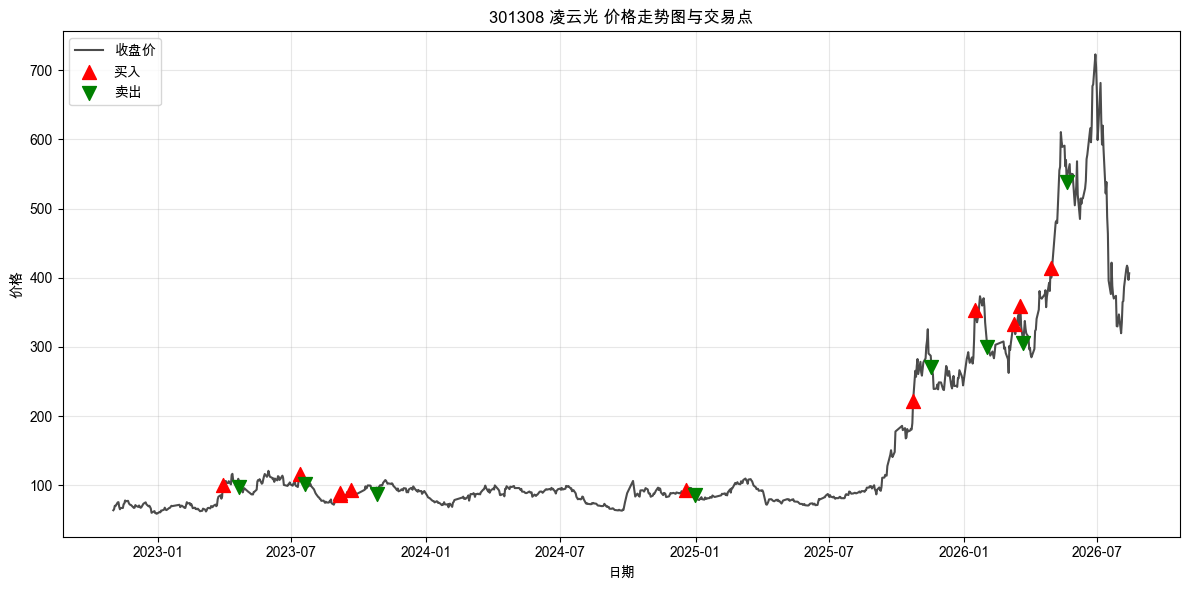


301308 凌云光 交易统计:
  买入次数: 11
  卖出次数: 8
  平均买入价: 204.96
  平均卖出价: 223.17


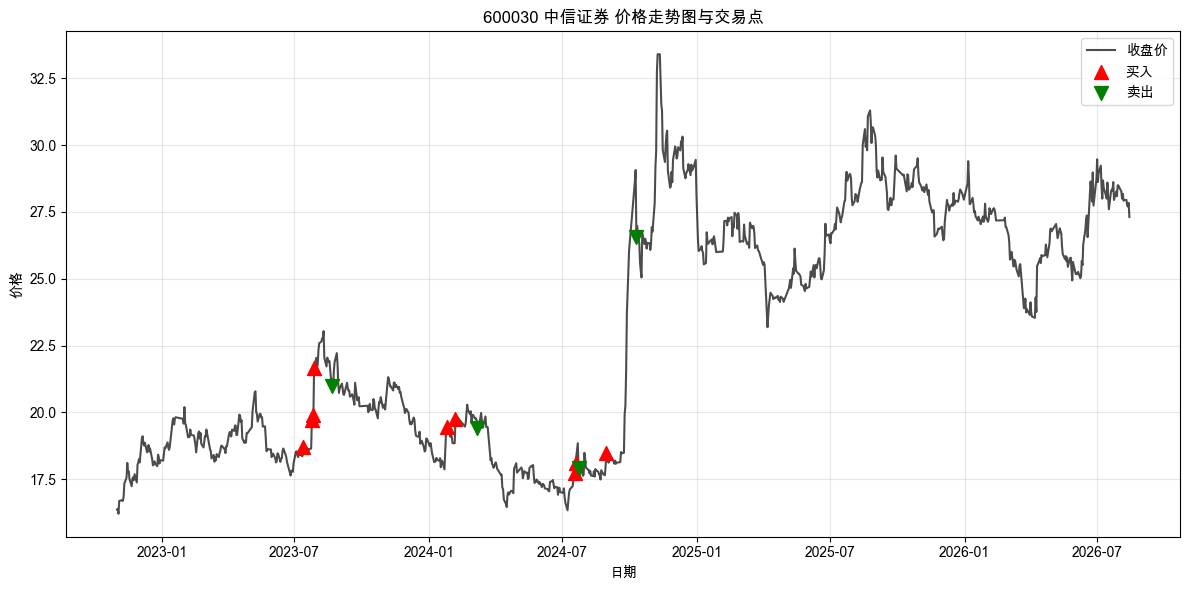


600030 中信证券 交易统计:
  买入次数: 9
  卖出次数: 4
  平均买入价: 19.28
  平均卖出价: 21.23


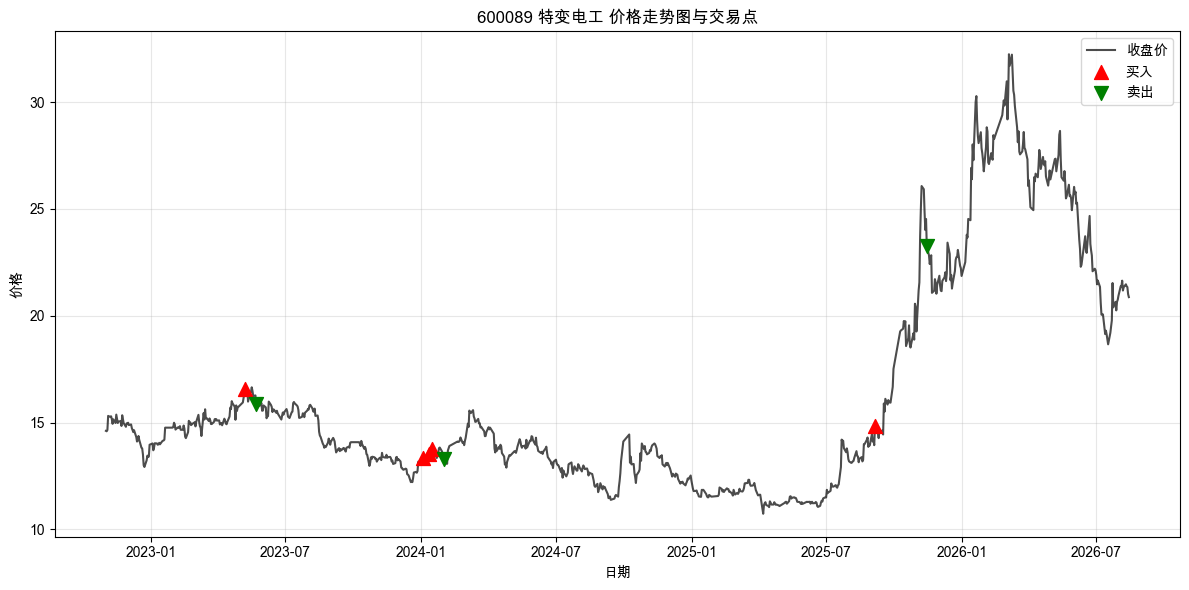


600089 特变电工 交易统计:
  买入次数: 5
  卖出次数: 3
  平均买入价: 14.41
  平均卖出价: 17.47


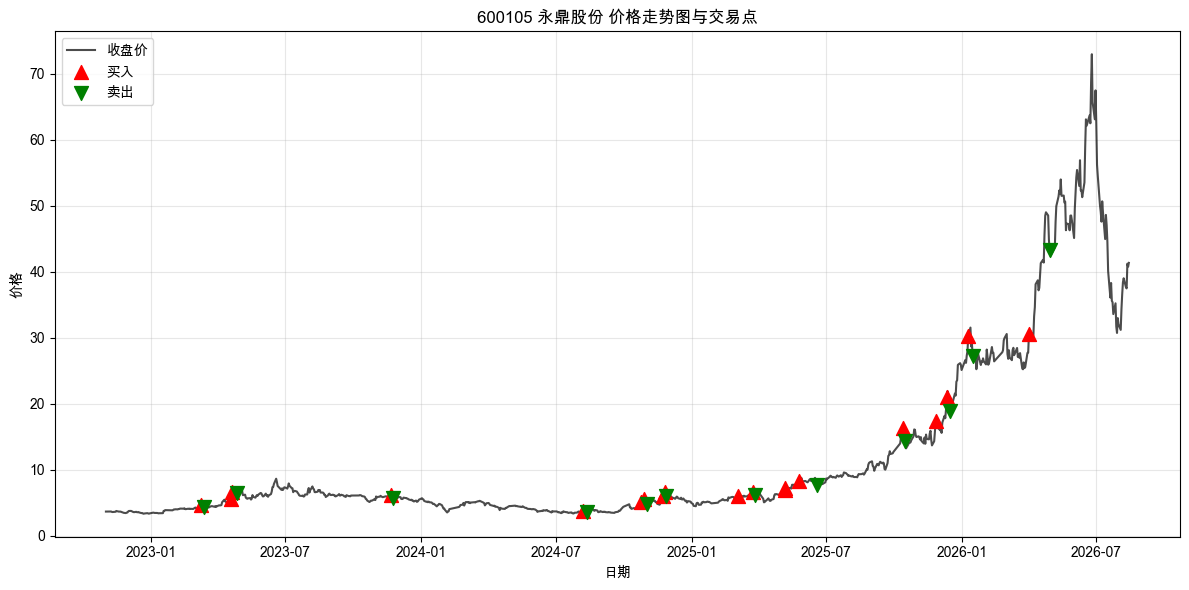


600105 永鼎股份 交易统计:
  买入次数: 19
  卖出次数: 12
  平均买入价: 10.54
  平均卖出价: 12.38


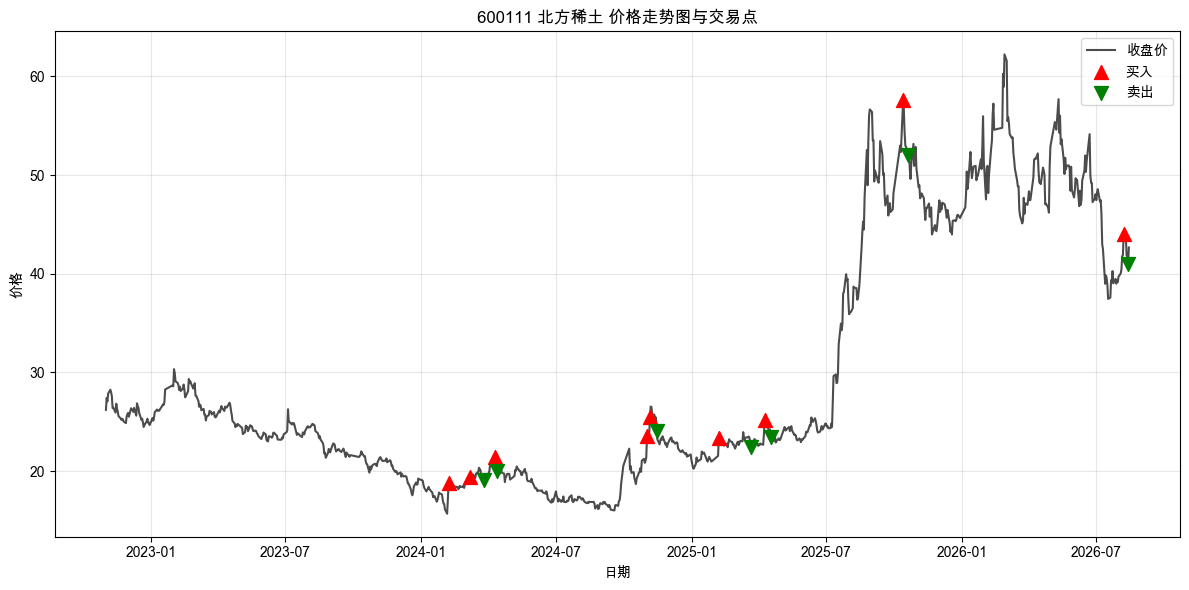


600111 北方稀土 交易统计:
  买入次数: 9
  卖出次数: 7
  平均买入价: 28.75
  平均卖出价: 28.87


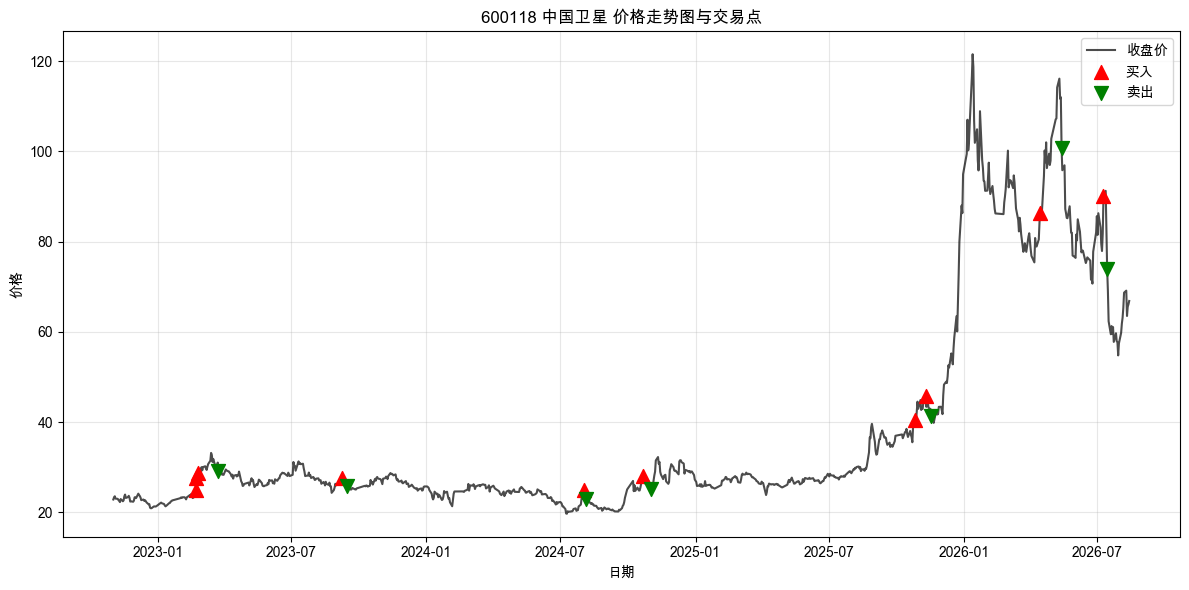


600118 中国卫星 交易统计:
  买入次数: 10
  卖出次数: 7
  平均买入价: 42.45
  平均卖出价: 45.62


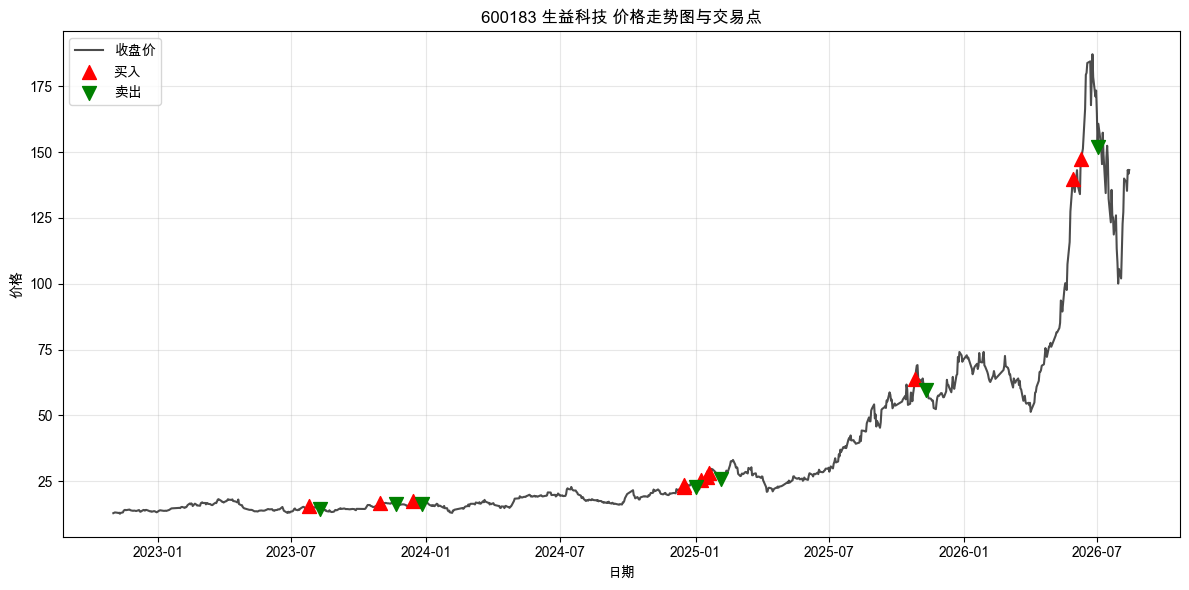


600183 生益科技 交易统计:
  买入次数: 11
  卖出次数: 7
  平均买入价: 47.96
  平均卖出价: 43.92


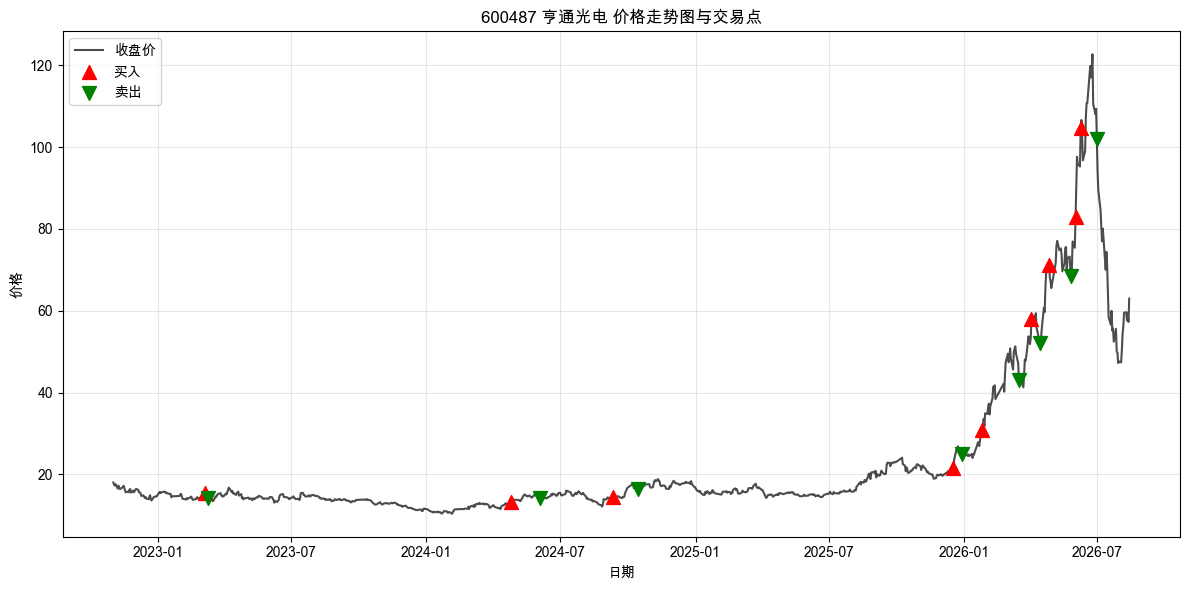


600487 亨通光电 交易统计:
  买入次数: 9
  卖出次数: 8
  平均买入价: 45.82
  平均卖出价: 41.88


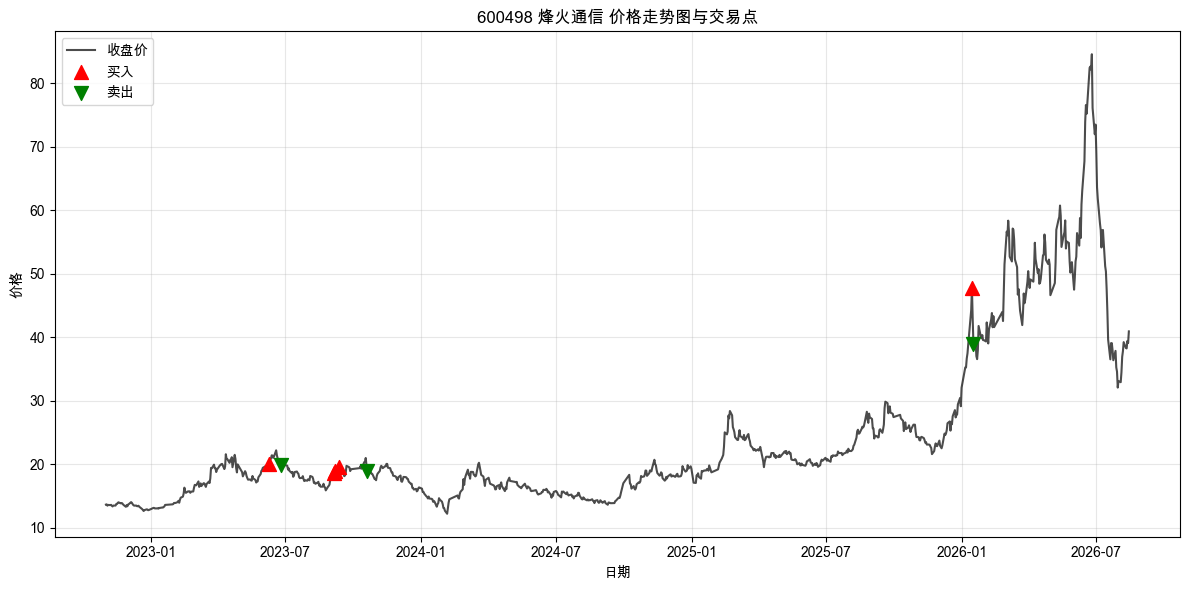


600498 烽火通信 交易统计:
  买入次数: 5
  卖出次数: 3
  平均买入价: 24.97
  平均卖出价: 25.93


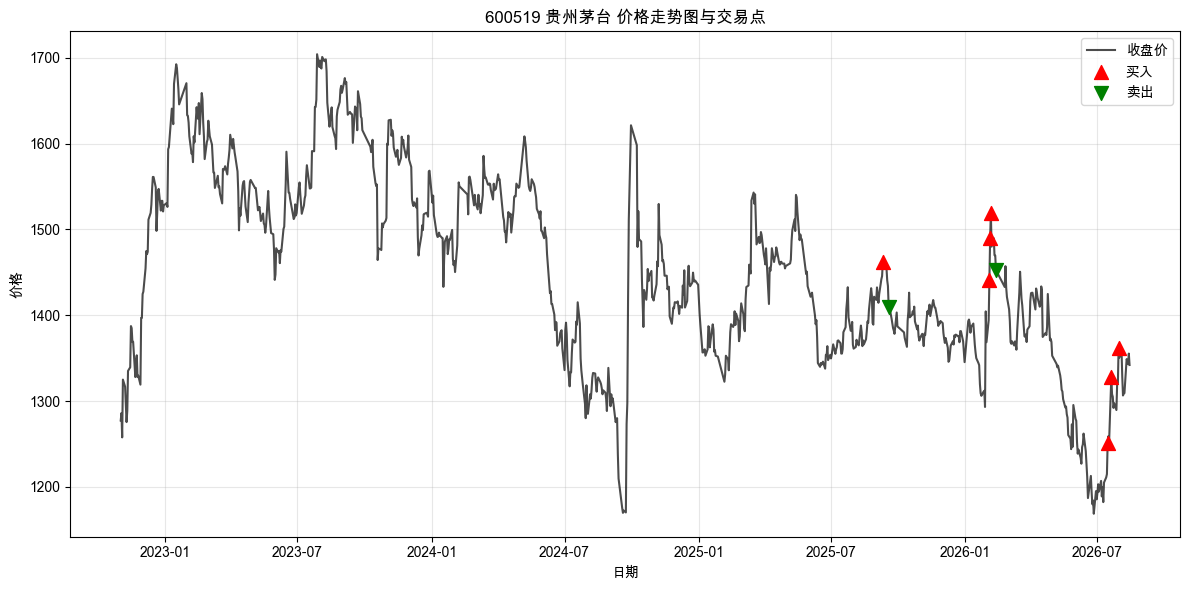


600519 贵州茅台 交易统计:
  买入次数: 7
  卖出次数: 2
  平均买入价: 1407.41
  平均卖出价: 1431.12


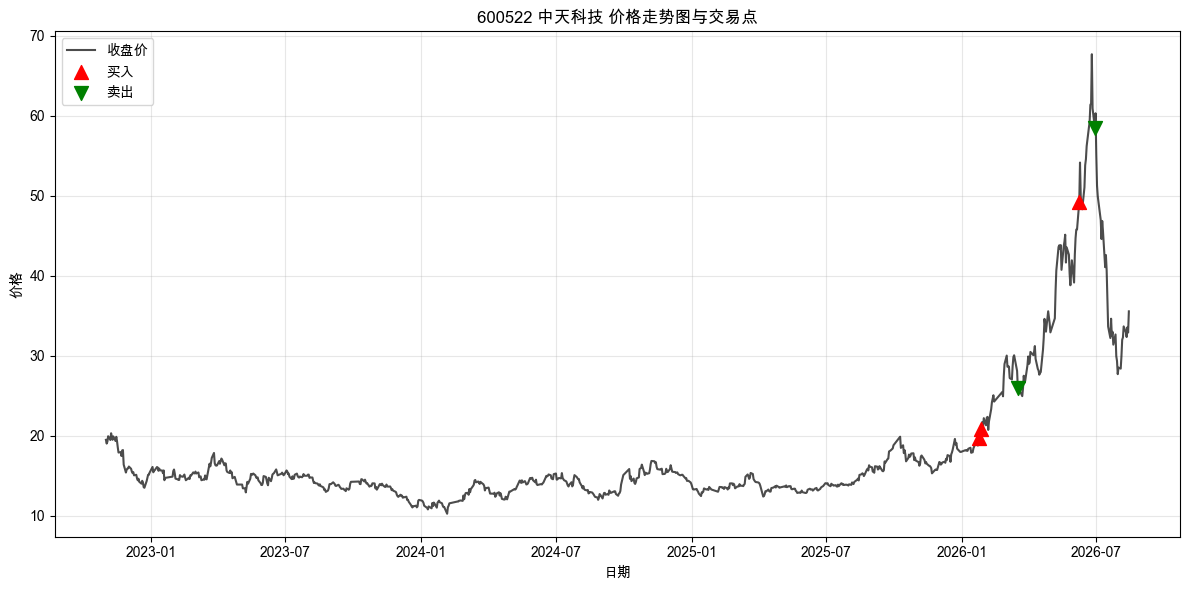


600522 中天科技 交易统计:
  买入次数: 3
  卖出次数: 2
  平均买入价: 29.91
  平均卖出价: 42.22


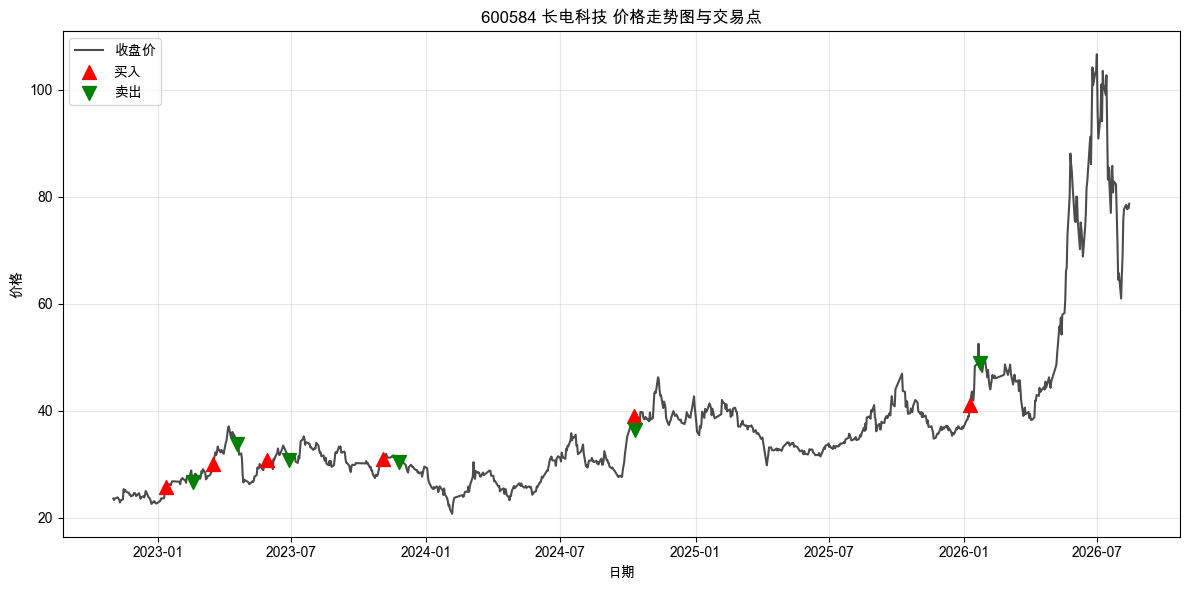


600584 长电科技 交易统计:
  买入次数: 6
  卖出次数: 6
  平均买入价: 32.98
  平均卖出价: 34.53


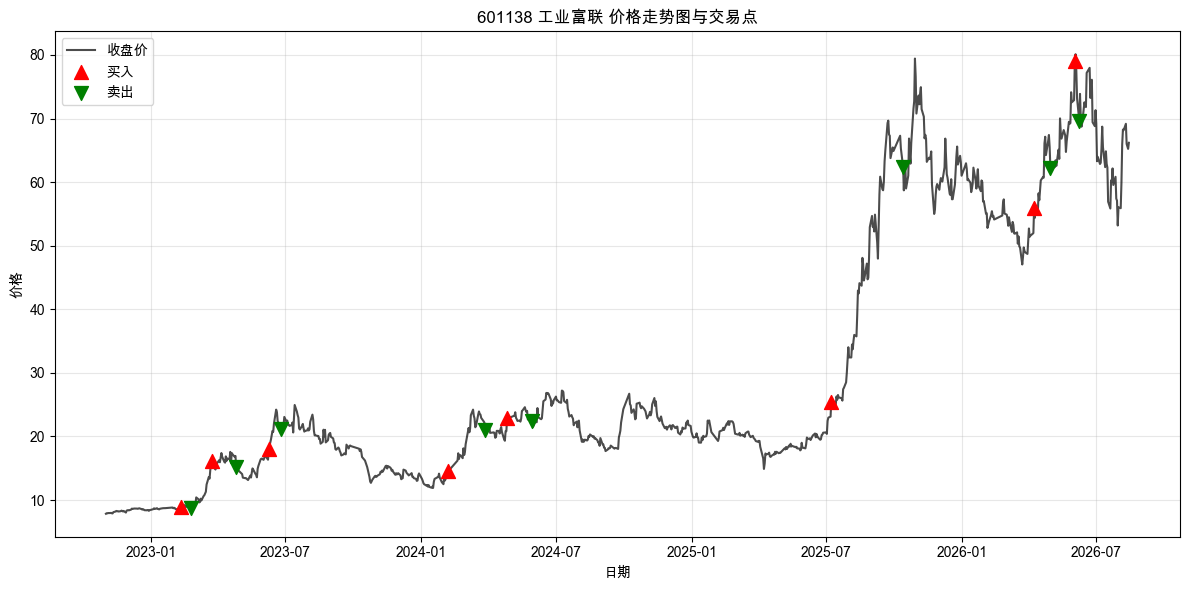


601138 工业富联 交易统计:
  买入次数: 8
  卖出次数: 8
  平均买入价: 30.13
  平均卖出价: 35.36


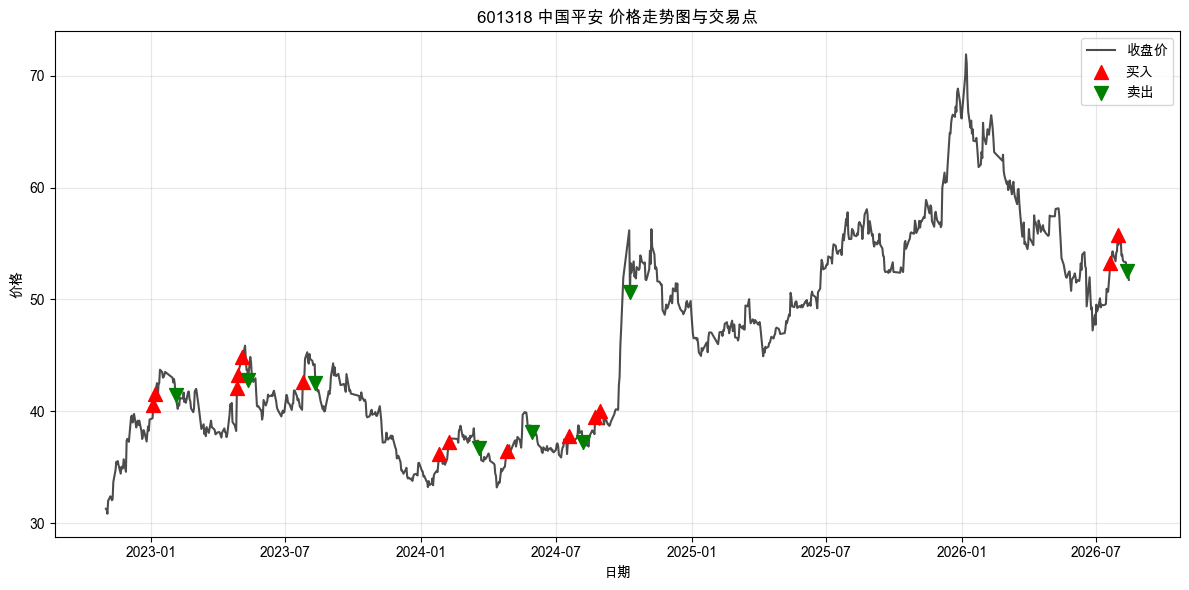


601318 中国平安 交易统计:
  买入次数: 14
  卖出次数: 8
  平均买入价: 42.22
  平均卖出价: 42.77


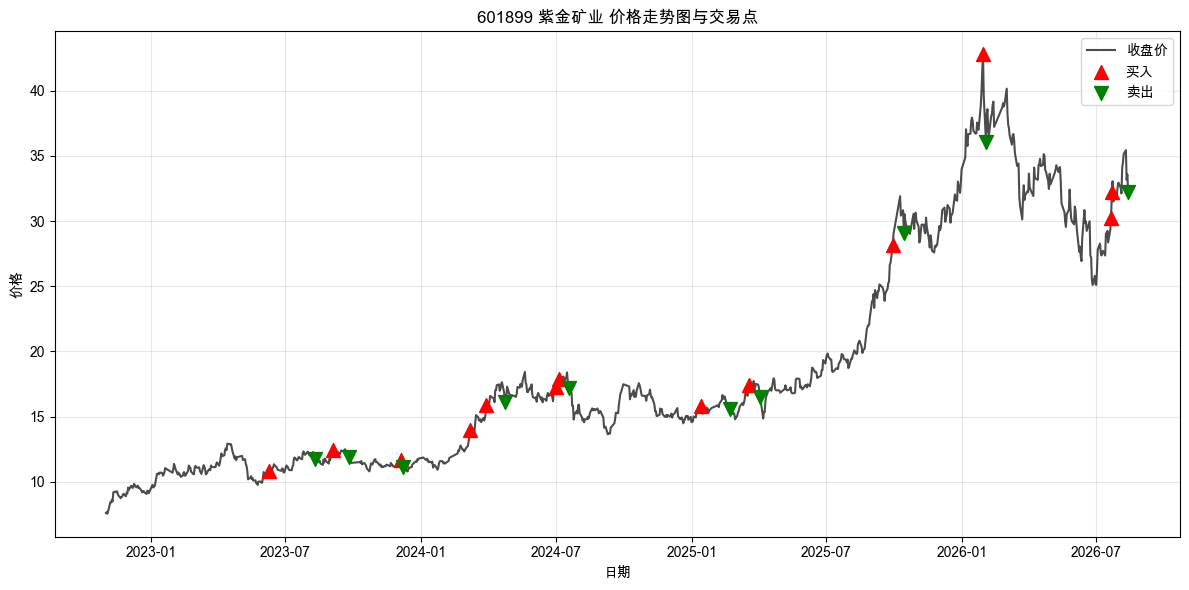


601899 紫金矿业 交易统计:
  买入次数: 13
  卖出次数: 10
  平均买入价: 20.50
  平均卖出价: 19.76


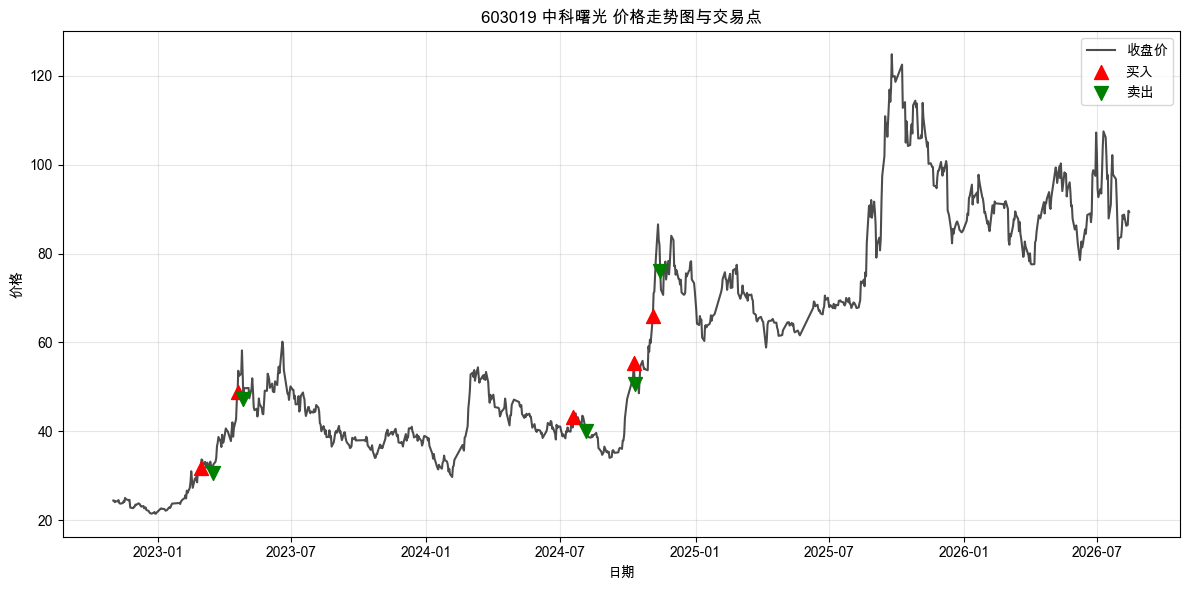


603019 中科曙光 交易统计:
  买入次数: 5
  卖出次数: 5
  平均买入价: 48.96
  平均卖出价: 48.88


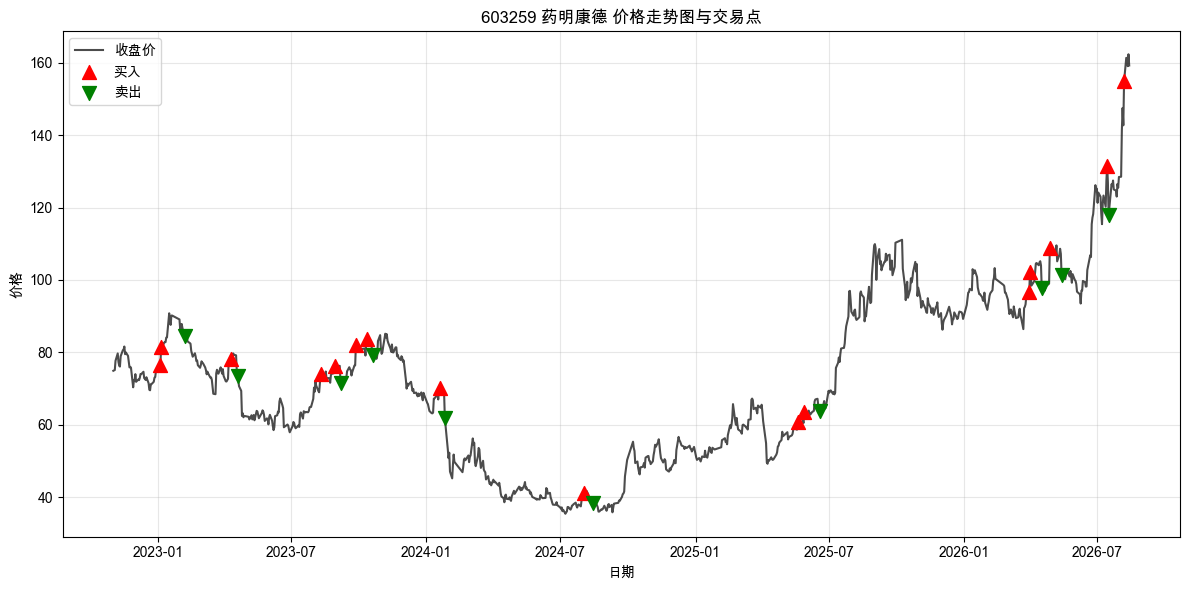


603259 药明康德 交易统计:
  买入次数: 16
  卖出次数: 10
  平均买入价: 86.34
  平均卖出价: 78.96


In [9]:
# 绘制每个持仓股票的价格走势图
import matplotlib.pyplot as plt
import matplotlib

# 配置中文字体
matplotlib.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

# 获取所有交易过的股票代码
traded_codes = set()
for trade in strategy.portfolio.trade_log:
    traded_codes.add(trade['code'])

# 为每个股票绘制价格图
for code in sorted(traded_codes):
    # 获取股票数据
    df = market_data.get(code)
    if df is None:
        continue
    
    # 获取股票名称
    stock_name = result.names.get(code, f'股票{code}')
    
    # 获取该股票的交易记录
    stock_trades = [t for t in strategy.portfolio.trade_log if t['code'] == code]
    
    # 分离买入和卖出交易
    buy_dates = [t['date'] for t in stock_trades if t['action'] == 'buy']
    buy_prices = [t['price'] for t in stock_trades if t['action'] == 'buy']
    sell_dates = [t['date'] for t in stock_trades if t['action'] == 'sell']
    sell_prices = [t['price'] for t in stock_trades if t['action'] == 'sell']
    
    # 创建图表
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # 绘制价格曲线
    ax.plot(df.index, df['close'], label='收盘价', color='black', alpha=0.7)
    
    # 绘制买入点
    if buy_dates and buy_prices:
        ax.scatter(buy_dates, buy_prices, color='red', marker='^', s=100, label='买入', zorder=5)
    
    # 绘制卖出点
    if sell_dates and sell_prices:
        ax.scatter(sell_dates, sell_prices, color='green', marker='v', s=100, label='卖出', zorder=5)
    
    # 设置图表标题和标签
    ax.set_title(f'{code} {stock_name} 价格走势图与交易点')
    ax.set_xlabel('日期')
    ax.set_ylabel('价格')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 显示图表
    plt.tight_layout()
    plt.show()
    
    print(f'\n{code} {stock_name} 交易统计:')
    print(f'  买入次数: {len(buy_dates)}')
    print(f'  卖出次数: {len(sell_dates)}')
    if buy_prices:
        print(f'  平均买入价: {sum(buy_prices)/len(buy_prices):.2f}')
    if sell_prices:
        print(f'  平均卖出价: {sum(sell_prices)/len(sell_prices):.2f}')

## 6. 月度收益分析

月度收益统计:
  平均月度收益: 5.10%
  月度收益标准差: 14.76%
  最佳月份: 52.14% (2025-08)
  最差月份: -16.82% (2026-07)
  盈利月份比例: 53.49%


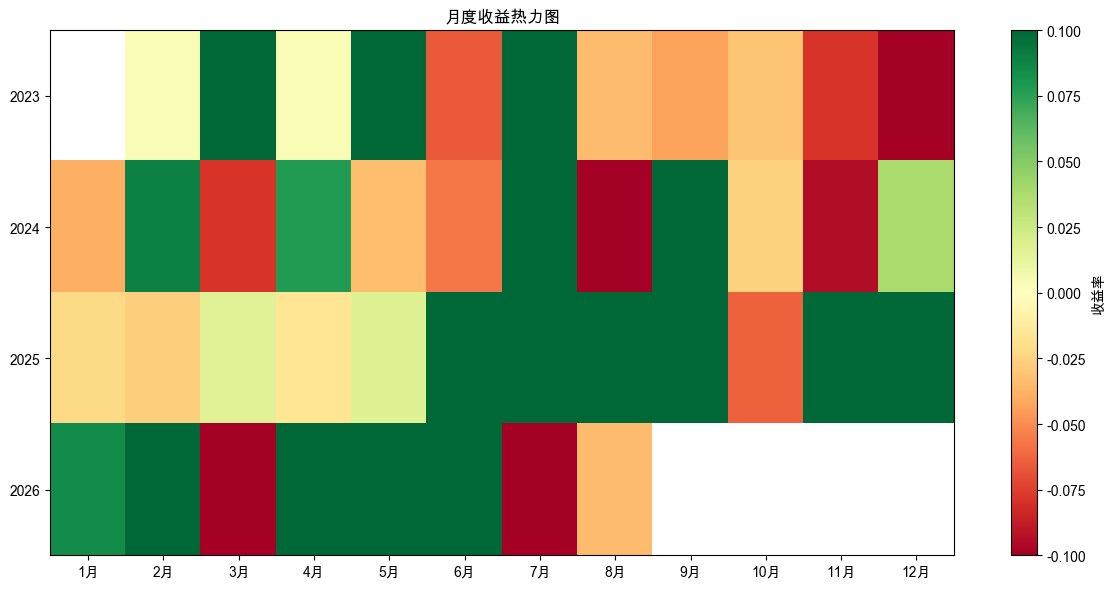

In [10]:
# 月度收益分析
monthly_returns = nav_history['nav'].resample('M').last().pct_change().dropna()

print('月度收益统计:')
print(f'  平均月度收益: {monthly_returns.mean():.2%}')
print(f'  月度收益标准差: {monthly_returns.std():.2%}')
print(f'  最佳月份: {monthly_returns.max():.2%} ({monthly_returns.idxmax().strftime("%Y-%m")})')
print(f'  最差月份: {monthly_returns.min():.2%} ({monthly_returns.idxmin().strftime("%Y-%m")})')
print(f'  盈利月份比例: {(monthly_returns > 0).mean():.2%}')

# 绘制月度收益热力图
monthly_returns_pivot = pd.DataFrame({
    'Year': monthly_returns.index.year,
    'Month': monthly_returns.index.month,
    'Return': monthly_returns.values
}).pivot(index='Year', columns='Month', values='Return')

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(monthly_returns_pivot.values, cmap='RdYlGn', aspect='auto', vmin=-0.1, vmax=0.1)
ax.set_xticks(range(12))
ax.set_xticklabels(['1月', '2月', '3月', '4月', '5月', '6月', '7月', '8月', '9月', '10月', '11月', '12月'])
ax.set_yticks(range(len(monthly_returns_pivot.index)))
ax.set_yticklabels(monthly_returns_pivot.index)
ax.set_title('月度收益热力图')
plt.colorbar(im, ax=ax, label='收益率')
plt.tight_layout()
plt.show()

## 7. 参数敏感性分析

In [11]:
# 参数敏感性分析
def run_sensitivity_analysis(market_data, param_name, param_values, base_params):
    """运行参数敏感性分析"""
    results = []
    
    for value in param_values:
        # 创建策略实例
        params = base_params.copy()
        params[param_name] = value
        
        strategy = ATRChannelStrategy(**params)
        nav_history = strategy.run(
            market_data=market_data,
            start_date='2023-01-01',
            end_date='2026-08-22'
        )
        
        # 计算绩效指标
        total_return = (nav_history['nav'].iloc[-1] / nav_history['nav'].iloc[0]) - 1
        max_drawdown = (nav_history['nav'] / nav_history['nav'].cummax() - 1).min()
        
        results.append({
            'param_value': value,
            'total_return': total_return,
            'max_drawdown': max_drawdown,
        })
        
        print(f'{param_name}={value}: 总收益率={total_return:.2%}, 最大回撤={max_drawdown:.2%}')
    
    return pd.DataFrame(results)

# 基础参数
base_params = {
    'initial_capital': 1_000_000,
    'ma_period': 20,
    'atr_period': 20,
    'atr_multiplier': 2.0,
    'initial_position_pct': 0.05,
    'max_position_pct': 0.10,
    'add_position_pct': 0.005,
    'atr_add_threshold': 0.5,
    'commission': 0.0003,
    'stamp_tax': 0.0005
}

# 测试不同 ATR 周期
print('测试不同 ATR 周期:')
atr_period_results = run_sensitivity_analysis(
    market_data, 'atr_period', [10, 14, 20, 30], base_params
)

# 测试不同 ATR 乘数
print('\n测试不同 ATR 乘数:')
atr_multiplier_results = run_sensitivity_analysis(
    market_data, 'atr_multiplier', [1.5, 2.0, 2.5, 3.0], base_params
)

测试不同 ATR 周期:


NameError: name 'ATRChannelStrategy' is not defined